<a href="https://www.kaggle.com/code/rahadul231/fake-news-detection-in-english-and-bangla?scriptVersionId=329978206" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Fake News Detection in Bangla and English: A Comparative Analysis of Classical Machine Learning and Transformer-Based Models

**Project Type:** Academic Thesis / Journal-style Experiment  
**Platform:** Kaggle Notebook  
**Languages:** English and Bangla  
**Methods:** TF-IDF, Logistic Regression, Multinomial Naive Bayes, Linear SVM, Random Forest, BanglaBERT, multilingual BERT, XLM-RoBERTa  
**Label Mapping:** `0 = Fake`, `1 = Real`

This notebook uses the final polished datasets prepared for Bangla and English fake-news detection. The datasets are already cleaned, balanced, and split into training, validation, and testing sets. Therefore, the notebook does **not** re-split the data. It loads the prepared splits directly, applies TF-IDF feature extraction, trains classical machine learning models, evaluates transformer-based baselines, compares Bangla and English results, and performs error analysis.

## Introduction

Fake news detection is an important natural language processing task because false or misleading information can influence public opinion, create social confusion, and reduce trust in reliable information sources. Automated fake news detection systems can help identify suspicious news content at scale.

Most fake news detection studies focus on English because it is a high-resource language with many available datasets and NLP tools. Bangla fake news detection is also important, especially for Bangladesh and Bengali-speaking communities, but Bangla is comparatively low-resource and has additional linguistic challenges such as spelling variation, rich morphology, informal writing, named-entity variation, and script-specific preprocessing issues.

This study performs a comparative analysis of fake news detection in Bangla and English using TF-IDF features and classical machine learning models. Bangla and English are handled separately because they have different linguistic structures and vocabulary patterns. The final results are compared to understand the behavior of classical machine learning models across low-resource and high-resource language settings.


## Research Objectives

1. To develop separate fake-news detection pipelines for English and Bangla news text.
2. To use cleaned and quality-controlled train, validation, and test datasets.
3. To apply TF-IDF feature extraction separately for each language.
4. To train and evaluate classical machine learning classifiers.
5. To evaluate transformer-based baseline models, including BanglaBERT, multilingual BERT, and XLM-RoBERTa.
6. To compare model performance between Bangla and English datasets.
7. To compare classical machine learning models with transformer-based contextual language models.
8. To identify the best-performing model for each language based on validation and test performance.
9. To analyze misclassified examples and discuss possible reasons for classification errors.
10. To examine model-associated TF-IDF features for interpretability.

## Research Questions

This study addresses the following research questions:

1. How effectively can classical machine learning models detect fake and real news in Bangla and English text?
2. Which classical machine learning model performs best for Bangla fake-news detection using TF-IDF features?
3. Which classical machine learning model performs best for English fake-news detection using TF-IDF features?
4. Do transformer-based models improve fake-news detection performance compared with TF-IDF-based classical machine learning models?
5. How does model performance differ between Bangla and English fake-news detection?
6. What types of misclassifications occur in Bangla and English fake-news detection, and what factors may contribute to these errors?

## Dataset Preparation Summary

This study uses a cleaned, balanced, and quality-controlled bilingual fake-news dataset prepared for Bangla and English fake-news detection.

The final modeling dataset contains 60,460 news samples in total:
- Bangla: 20,440 samples
- English: 40,020 samples

For both languages, the label mapping is:
- 0 = Fake News
- 1 = Real News

The datasets were split into training, validation, and test sets using a 70% / 10% / 20% split. The training set was used for model fitting, the validation set was used for model comparison and hyperparameter selection, and the test set was reserved for final performance reporting.

Important note: the final polished files used for modeling contain only standardized text and label columns. Row-level original source identifiers were not preserved in the final files. Therefore, source information is reported at the dataset-construction level rather than at the individual-record level.

## Main Contributions

The main contributions of this study are:

1. A comparative fake-news detection pipeline for Bangla and English news text.
2. Use of cleaned, balanced, and quality-controlled datasets for both languages.
3. Separate TF-IDF feature extraction for Bangla and English to preserve language-specific characteristics.
4. Evaluation of multiple classical machine learning models, including Logistic Regression, Multinomial Naive Bayes, Linear SVM, and Random Forest.
5. Evaluation of transformer-based baseline models, including BanglaBERT, multilingual BERT, and XLM-RoBERTa.
6. Comparison between classical feature-based models and contextual transformer-based models.
7. Performance comparison using accuracy, precision, recall, F1-score, macro-F1, ROC-AUC, confidence intervals, and confusion matrices.
8. Error analysis and TF-IDF feature interpretation to understand model behavior beyond numerical performance.

### Final train, validation, and test distribution

| Language | Dataset split | Total samples | Fake news `0` | Real news `1` |
|---|---:|---:|---:|---:|
| Bangla | Training | 14,308 | 7,154 | 7,154 |
| Bangla | Validation | 2,044 | 1,022 | 1,022 |
| Bangla | Testing | 4,088 | 2,044 | 2,044 |
| English | Training | 28,014 | 14,007 | 14,007 |
| English | Validation | 4,002 | 2,001 | 2,001 |
| English | Testing | 8,004 | 4,002 | 4,002 |
| **Total** | — | **60,460** | **30,230** | **30,230** |

In [1]:
# Step 1: Import Required Libraries and Check Package Versions

import os
import re
import sys
import warnings
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import statsmodels

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
LABEL_MAP = {0: "Fake News", 1: "Real News"}

print("Libraries imported successfully.")

print("\nPython version:")
print(sys.version)

print("\nPackage versions:")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)

Libraries imported successfully.

Python version:
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Package versions:
pandas: 2.3.3
numpy: 2.4.6
scikit-learn: 1.6.1
statsmodels: 0.14.6


In [2]:
# Step 2: Check Dataset Paths in Kaggle

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/bangla train.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/english train.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/bangla validation.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/external evaluation of Bangla.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/english validation.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/english test.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/external evaluation of English.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/bangla test.csv


In [3]:
# Step 3: Automatically Find Final Dataset Files

import zipfile
from pathlib import Path

required_files = {
    "english_train": "english train.csv",
    "english_validation": "english validation.csv",
    "english_test": "english test.csv",
    "bangla_train": "bangla train.csv",
    "bangla_validation": "bangla validation.csv",
    "bangla_test": "bangla test.csv"
}

search_roots = [
    Path("/kaggle/input"),
    Path("/mnt/data"),
    Path(".")
]

extraction_dir = Path("/kaggle/working/extracted_final_curated_dataset")
extraction_dir.mkdir(parents=True, exist_ok=True)

# If the final dataset is uploaded as a ZIP file, extract it safely.
for root in list(search_roots):
    if root.exists():
        for zip_path in root.rglob("*.zip"):
            try:
                with zipfile.ZipFile(zip_path, "r") as zf:
                    zip_names = [Path(name).name.lower().strip() for name in zf.namelist()]
                    required_names = [file_name.lower().strip() for file_name in required_files.values()]

                    if all(file_name in zip_names for file_name in required_names):
                        zf.extractall(extraction_dir)
                        print(f"Extracted dataset ZIP: {zip_path}")
                        search_roots.append(extraction_dir)
                        break
            except zipfile.BadZipFile:
                continue

found_paths = {}

for root in search_roots:
    if root.exists():
        for path in root.rglob("*.csv"):
            current_name = path.name.lower().strip()

            for key, required_name in required_files.items():
                if current_name == required_name.lower().strip() and key not in found_paths:
                    found_paths[key] = str(path)

print("Found dataset files:")
for key in required_files:
    if key in found_paths:
        print(f"{key}: {found_paths[key]}")
    else:
        print(f"{key}: NOT FOUND")

missing = [name for key, name in required_files.items() if key not in found_paths]

if missing:
    raise FileNotFoundError(
        "Missing required dataset files: "
        + ", ".join(missing)
        + ". Upload the final curated dataset package containing all six CSV files."
    )

print("\nAll required final curated dataset files found successfully.")

Found dataset files:
english_train: /kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/english train.csv
english_validation: /kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/english validation.csv
english_test: /kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/english test.csv
bangla_train: /kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/bangla train.csv
bangla_validation: /kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/bangla validation.csv
bangla_test: /kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/bangla test.csv

All required final curated dataset files found successfully.


## Dataset Source and Provenance

The dataset was compiled from publicly available Bangla and English fake-news resources. During final preparation, all text fields were standardized into a common two-column format: `text` and `label`.

The final dataset does not preserve row-level source identifiers. Therefore, exact record-level tracing back to each original dataset is not possible from the final polished CSV files alone. To maintain transparency, this notebook reports source information at the dataset-construction level and clearly identifies excluded sources.

For manuscript submission, each original dataset should be cited using its verified public source link, access date, license, original sample count, and final usage decision.

In [4]:
# Step 4: Publication-Safe Dataset Source, License, and Access-Date Table

# IMPORTANT:
# Access date means the date you accessed/downloaded/verified the source page.
# Change this date if your actual access date is different.

DATASET_ACCESS_DATE = "2026-06-19"

dataset_source_table = pd.DataFrame([
    {
        "Use": "Bangla main dataset",
        "Dataset name": "BanFakeNews-2.0",
        "Local file name": "All60Kdataset.csv",
        "Source URL": "https://data.mendeley.com/datasets/kjh887ct4j/1",
        "Alternative source": "https://www.kaggle.com/datasets/hrithikmajumdar/bangla-fake-news",
        "Publication / update date": "2024-06-04",
        "Access date": DATASET_ACCESS_DATE,
        "Original size / note": "About 47,000 authentic and 13,000 fake Bangla news articles",
        "Original label mapping": "1 = authentic/real, 0 = fake",
        "Notebook label mapping": "0 = fake, 1 = real",
        "License": "CC BY 4.0",
        "License verification status": "Verified from Mendeley Data page",
        "Decision": "Used as recent Bangla main source"
    },
    {
        "Use": "English main dataset",
        "Dataset name": "Fake News Classification",
        "Local file name": "English source CSV from Kaggle",
        "Source URL": "https://www.kaggle.com/datasets/aadyasingh55/fake-news-classification",
        "Alternative source": "None",
        "Publication / update date": "2024-10-22",
        "Access date": DATASET_ACCESS_DATE,
        "Original size / note": "Just over 45,000 English news articles",
        "Original label mapping": "0 = false/fake, 1 = true/real",
        "Notebook label mapping": "0 = fake, 1 = real",
        "License": "Apache 2.0",
        "License verification status": "Verified from Kaggle / indexed dataset metadata",
        "Decision": "Used as English main source"
    },
    {
        "Use": "English external evaluation",
        "Dataset name": "external evaluation of English",
        "Local file name": "external evaluation of English.csv",
        "Source URL": "https://www.kaggle.com/datasets/stevenpeutz/misinformation-fake-news-text-dataset-79k",
        "Alternative source": "None",
        "Publication / update date": "2022/2023 Kaggle source",
        "Access date": DATASET_ACCESS_DATE,
        "Original size / note": "Original source contains TRUE and FAKE/misinformation files; final prepared evaluation file contains 34,001 fake and 34,001 real samples",
        "Original label mapping": "TRUE file = real, FAKE file = fake",
        "Notebook label mapping": "0 = fake, 1 = real",
        "License": "GNU Lesser General Public License 3.0",
        "License verification status": "Verified from Kaggle / indexed dataset metadata",
        "Decision": "Used as independent English external evaluation after structural cleaning, label assignment, balancing, and shuffling"
    },
    {
        "Use": "Bangla external evaluation",
        "Dataset name": "external evaluation of Bangla",
        "Local file name": "external evaluation of Bangla.csv",
        "Source URL": "https://data.mendeley.com/datasets/k5pbz9795f/1; https://www.kaggle.com/datasets/evilspirit05/bengali-fake-news-dataset",
        "Alternative source": "MultiBanFakeDetect 2024 + Bengali Fake News Dataset cleanbn_fakenews.csv",
        "Publication / update date": "2024 / source-specific dates",
        "Access date": DATASET_ACCESS_DATE,
        "Original size / note": "Final prepared external Bangla file contains 18,150 samples: 9,075 fake and 9,075 real",
        "Original label mapping": "MultiBanFakeDetect: 1 = fake and 0 = non-fake; cleanbn_fakenews: 0 = fake and 1 = real/authentic",
        "Notebook label mapping": "0 = fake, 1 = real",
        "License": "MultiBanFakeDetect: CC BY 4.0; cleanbn_fakenews source license should be verified from the exact Kaggle source page before final manuscript",
        "License verification status": "MultiBanFakeDetect verified; cleanbn_fakenews source page should be manually verified before final submission",
        "Decision": "Used as independent Bangla external evaluation after duplicate removal, internal-overlap removal, label standardization, balancing, and shuffling"        
    },
    {
        "Use": "Excluded",
        "Dataset name": "BanglaBait / clickbait-style files",
        "Local file name": "train.csv, dev.csv, test.csv, unlabelled_data.csv",
        "Source URL": "Record exact Kaggle/source URL only if cited",
        "Alternative source": "None",
        "Publication / update date": "Recent source, exact date should be checked only if cited",
        "Access date": DATASET_ACCESS_DATE,
        "Original size / note": "Clickbait/non-clickbait task, not pure fake/real news",
        "Original label mapping": "Task-specific clickbait labels",
        "Notebook label mapping": "Not used",
        "License": "Not used in this study",
        "License verification status": "Not required because excluded",
        "Decision": "Excluded to keep the study focused on fake-news detection"
    },
    {
        "Use": "Excluded",
        "Dataset name": "Image-based or multimodal files",
        "Local file name": "Bang-English fake news dataset.zip / Dataset.zip",
        "Source URL": "Record exact source URL only if cited",
        "Alternative source": "None",
        "Publication / update date": "Recent source, exact date should be checked only if cited",
        "Access date": DATASET_ACCESS_DATE,
        "Original size / note": "Image-based or multimodal data",
        "Original label mapping": "Not applicable for text-only TF-IDF pipeline",
        "Notebook label mapping": "Not used",
        "License": "Not used in this text-only study",
        "License verification status": "Not required because excluded",
        "Decision": "Excluded from this text-only notebook"
    }
])

display(dataset_source_table)
dataset_source_table.to_csv("publication_safe_dataset_source_table.csv", index=False)

,Use,Dataset name,Local file name,Source URL,Alternative source,Publication / update date,Access date,Original size / note,Original label mapping,Notebook label mapping,License,License verification status,Decision
0,Bangla main dataset,BanFakeNews-2.0,All60Kdataset.csv,https://data.mendeley.com/datasets/kjh887ct4j/1,https://www.kaggle.com/datasets/hrithikmajumdar/bangla-fake-news,2024-06-04,2026-06-19,"About 47,000 authentic and 13,000 fake Bangla news articles","1 = authentic/real, 0 = fake","0 = fake, 1 = real",CC BY 4.0,Verified from Mendeley Data page,Used as recent Bangla main source
1,English main dataset,Fake News Classification,English source CSV from Kaggle,https://www.kaggle.com/datasets/aadyasingh55/fake-news-classification,None,2024-10-22,2026-06-19,"Just over 45,000 English news articles","0 = false/fake, 1 = true/real","0 = fake, 1 = real",Apache 2.0,Verified from Kaggle / indexed dataset metadata,Used as English main source
2,English external evaluation,external evaluation of English,external evaluation of English.csv,https://www.kaggle.com/datasets/stevenpeutz/misinformation-fake-news-text-dataset-79k,None,2022/2023 Kaggle source,2026-06-19,"Original source contains TRUE and FAKE/misinformation files; final prepared evaluation file contains 34,001 fake and...","TRUE file = real, FAKE file = fake","0 = fake, 1 = real",GNU Lesser General Public License 3.0,Verified from Kaggle / indexed dataset metadata,"Used as independent English external evaluation after structural cleaning, label assignment, balancing, and shuffling"
3,Bangla external evaluation,external evaluation of Bangla,external evaluation of Bangla.csv,https://data.mendeley.com/datasets/k5pbz9795f/1; https://www.kaggle.com/datasets/evilspirit05/bengali-fake-news-dataset,MultiBanFakeDetect 2024 + Bengali Fake News Dataset cleanbn_fakenews.csv,2024 / source-specific dates,2026-06-19,"Final prepared external Bangla file contains 18,150 samples: 9,075 fake and 9,075 real",MultiBanFakeDetect: 1 = fake and 0 = non-fake; cleanbn_fakenews: 0 = fake and 1 = real/authentic,"0 = fake, 1 = real",MultiBanFakeDetect: CC BY 4.0; cleanbn_fakenews source license should be verified from the exact Kaggle source page ...,MultiBanFakeDetect verified; cleanbn_fakenews source page should be manually verified before final submission,"Used as independent Bangla external evaluation after duplicate removal, internal-overlap removal, label standardizat..."
4,Excluded,BanglaBait / clickbait-style files,"train.csv, dev.csv, test.csv, unlabelled_data.csv",Record exact Kaggle/source URL only if cited,None,"Recent source, exact date should be checked only if cited",2026-06-19,"Clickbait/non-clickbait task, not pure fake/real news",Task-specific clickbait labels,Not used,Not used in this study,Not required because excluded,Excluded to keep the study focused on fake-news detection
5,Excluded,Image-based or multimodal files,Bang-English fake news dataset.zip / Dataset.zip,Record exact source URL only if cited,None,"Recent source, exact date should be checked only if cited",2026-06-19,Image-based or multimodal data,Not applicable for text-only TF-IDF pipeline,Not used,Not used in this text-only study,Not required because excluded,Excluded from this text-only notebook


## Source Traceability Note

The final polished modeling files used in this notebook contain standardized `text` and `label` columns. Row-level source identifiers such as `source_dataset`, `source_file`, and `source_row_id` were not preserved during the earlier manual merging and cleaning process. Therefore, exact row-level source reconstruction is not guaranteed from the final split files alone.

To maintain transparency, this notebook reports dataset provenance at the dataset-construction level. For a future fully reproducible publication version, the dataset should be rebuilt from the original verified raw files while preserving `source_dataset`, `source_file`, `source_row_id`, source URL, access date, and license information for every row.

In [5]:
# Step 5: Related Work and Dataset Comparison Table

related_work_table = pd.DataFrame([
    {
        "Study / Dataset": "BanFakeNews",
        "Language": "Bangla",
        "Dataset size": "Approximately 50K",
        "Main approach": "Traditional and neural NLP methods",
        "Use in current study": "Background Bangla fake-news benchmark",
        "Limitation / note": "Older than BanFakeNews-2.0"
    },
    {
        "Study / Dataset": "BanFakeNews-2.0",
        "Language": "Bangla",
        "Dataset size": "About 60K",
        "Main approach": "Large Bangla fake-news dataset",
        "Use in current study": "Main Bangla source for the internal modeling dataset",
        "Limitation / note": "Original source is imbalanced before cleaning and balancing"
    },
    {
        "Study / Dataset": "MultiBanFakeDetect 2024",
        "Language": "Bangla",
        "Dataset size": "9,600 text-image instances",
        "Main approach": "Multimodal Bangla fake-news detection",
        "Use in current study": "Part of the final Bangla external evaluation dataset using text fields only",
        "Limitation / note": "Original task is multimodal; this notebook uses headline and description only"
    },
    {
        "Study / Dataset": "Bengali Fake News Dataset / cleanbn_fakenews.csv",
        "Language": "Bangla",
        "Dataset size": "Source-specific Bangla fake/real news file",
        "Main approach": "Bangla fake-news detection",
        "Use in current study": "Part of the final Bangla external evaluation dataset",
        "Limitation / note": "Used only after duplicate removal, internal-overlap removal, label checking, and balancing"
    },
    {
        "Study / Dataset": "Fake News Classification",
        "Language": "English",
        "Dataset size": "Just over 45K",
        "Main approach": "English fake/real news classification",
        "Use in current study": "Main English source for the internal modeling dataset",
        "Limitation / note": "Should not be reused as an independent external test if included in training"
    },
    {
        "Study / Dataset": "Misinformation & Fake News text dataset 79K",
        "Language": "English",
        "Dataset size": "About 79K",
        "Main approach": "English misinformation/fake/propaganda classification",
        "Use in current study": "Final independent English external evaluation dataset",
        "Limitation / note": "Used after label assignment, structural cleaning, duplicate removal, balancing, and shuffling"
    },
    {
        "Study / Dataset": "Current study",
        "Language": "Bangla and English",
        "Dataset size": "60,460 internal modeling samples + separate external evaluation datasets",
        "Main approach": "TF-IDF classical ML + transformer baselines + external evaluation",
        "Use in current study": "Main comparative experiment",
        "Limitation / note": "Internal polished files do not preserve row-level source IDs"
    }
])

display(related_work_table)
related_work_table.to_csv("related_work_dataset_comparison.csv", index=False)

,Study / Dataset,Language,Dataset size,Main approach,Use in current study,Limitation / note
0,BanFakeNews,Bangla,Approximately 50K,Traditional and neural NLP methods,Background Bangla fake-news benchmark,Older than BanFakeNews-2.0
1,BanFakeNews-2.0,Bangla,About 60K,Large Bangla fake-news dataset,Main Bangla source for the internal modeling dataset,Original source is imbalanced before cleaning and balancing
2,MultiBanFakeDetect 2024,Bangla,"9,600 text-image instances",Multimodal Bangla fake-news detection,Part of the final Bangla external evaluation dataset using text fields only,Original task is multimodal; this notebook uses headline and description only
3,Bengali Fake News Dataset / cleanbn_fakenews.csv,Bangla,Source-specific Bangla fake/real news file,Bangla fake-news detection,Part of the final Bangla external evaluation dataset,"Used only after duplicate removal, internal-overlap removal, label checking, and balancing"
4,Fake News Classification,English,Just over 45K,English fake/real news classification,Main English source for the internal modeling dataset,Should not be reused as an independent external test if included in training
5,Misinformation & Fake News text dataset 79K,English,About 79K,English misinformation/fake/propaganda classification,Final independent English external evaluation dataset,"Used after label assignment, structural cleaning, duplicate removal, balancing, and shuffling"
6,Current study,Bangla and English,"60,460 internal modeling samples + separate external evaluation datasets",TF-IDF classical ML + transformer baselines + external evaluation,Main comparative experiment,Internal polished files do not preserve row-level source IDs


In [6]:
# Step 6: Load English and Bangla Train/Validation/Test Files

english_train = pd.read_csv(found_paths["english_train"])
english_validation = pd.read_csv(found_paths["english_validation"])
english_test = pd.read_csv(found_paths["english_test"])

bangla_train = pd.read_csv(found_paths["bangla_train"])
bangla_validation = pd.read_csv(found_paths["bangla_validation"])
bangla_test = pd.read_csv(found_paths["bangla_test"])

print("English Train Shape:", english_train.shape)
print("English Validation Shape:", english_validation.shape)
print("English Test Shape:", english_test.shape)

print("\nBangla Train Shape:", bangla_train.shape)
print("Bangla Validation Shape:", bangla_validation.shape)
print("Bangla Test Shape:", bangla_test.shape)


English Train Shape: (28014, 2)
English Validation Shape: (4002, 2)
English Test Shape: (8004, 2)

Bangla Train Shape: (14308, 2)
Bangla Validation Shape: (2044, 2)
Bangla Test Shape: (4088, 2)


In [7]:
# Step 7: Display First Few Rows

print("English Training Data Preview:")
display(english_train.head())

print("\nBangla Training Data Preview:")
display(bangla_train.head())


English Training Data Preview:


,text,label
0,trump ask saudi arabia allow immedi aid yemen us presid donald trump call saudi arabia wednesday immedi allow humani...,1
1,trump s alt right hillary s alt left in an attempt to give moderate republicans who are disturbed by donald trump an...,1
2,trump pledg reform veteran administr elect charlott nc republican presidenti nomine donald trump sought turn scandal...,1
3,on to indy hoosier state could be stand for trump challengers sanders on to indy hoosier state could be stand for tr...,1
4,white hous welcom us court rule carbon emiss plan white hous said thursday pleas us appel court deni bid state block...,1



Bangla Training Data Preview:


,text,label
0,পরিবেশ বাঁচাতে শেষ সতর্কবার্তা ক্রমবর্ধমান বৈশ্বিক তাপমাত্রা নিয়ে শেষ সতর্কবার্তা জানিয়েছেন পরিবেশবিজ্ঞানীরা। বৈশ্...,1
1,একাউন্ট হবে: তারেক লনডন মতিনিধি ফেসবু তারেক জিয় একাউন্ট বৃহত্তর জামায়া ইসলামীর বিএনপি শাখ ভাঁড়প্রাপ্ত নায়াব আমীর...,0
2,মাশরাফি হারামজাদা মাশরাফি পড় এমপি হওয়া লোভ বড় মানুষ কইরাই ডোবে! থাক লইয়া ক্রিকেট রাজনীতি রাজনীতি হাত পাউরুটি জেল...,0
3,মাইক টাই বডিগার্ড হ শেরা বলিউড ভাই সঙ্গ ছাড় সঙ্গী শেরা। থাক মাইক টাই বডিগার্ড হিসাব শুক্রবার ভারত ভ্রমণ এসেছেন তারকা...,1
4,"শনিবারের রাশিফল (২৯ সেপ্টেম্বর) অপমানিত হওয়ার শঙ্কা মিথুনের, বাড়তি খরচ তুলার মেষ: আজ সকাল থেকে খরচ বৃদ্ধির সম্ভাবন...",1


In [8]:
# Step 8: Select Necessary Columns

# English columns: text, label
# Bangla columns: text, label

english_train = english_train[["text", "label"]]
english_validation = english_validation[["text", "label"]]
english_test = english_test[["text", "label"]]

bangla_train = bangla_train[["text", "label"]]
bangla_validation = bangla_validation[["text", "label"]]
bangla_test = bangla_test[["text", "label"]]

print("English Selected Columns:")
print(english_train.columns)

print("\nBangla Selected Columns:")
print(bangla_train.columns)


English Selected Columns:
Index(['text', 'label'], dtype='object')

Bangla Selected Columns:
Index(['text', 'label'], dtype='object')


In [9]:
# Step 9: Basic Data Type Standardization

all_datasets = [
    english_train, english_validation, english_test,
    bangla_train, bangla_validation, bangla_test
]

for df in all_datasets:
    df["text"] = df["text"].astype(str)
    df["label"] = df["label"].astype(int)

print("Data types after standardization:")
print(english_train.dtypes)


Data types after standardization:
text     object
label     int64
dtype: object


In [10]:
# Step 10: Check Label Values and Expected Final Dataset Counts

expected_counts = {
    "English Train": {0: 14007, 1: 14007},
    "English Validation": {0: 2001, 1: 2001},
    "English Test": {0: 4002, 1: 4002},
    "Bangla Train": {0: 7154, 1: 7154},
    "Bangla Validation": {0: 1022, 1: 1022},
    "Bangla Test": {0: 2044, 1: 2044}
}

dataset_lookup = {
    "English Train": english_train,
    "English Validation": english_validation,
    "English Test": english_test,
    "Bangla Train": bangla_train,
    "Bangla Validation": bangla_validation,
    "Bangla Test": bangla_test
}

label_check_rows = []

for dataset_name, df in dataset_lookup.items():
    counts = df["label"].value_counts().sort_index().to_dict()
    counts = {int(k): int(v) for k, v in counts.items()}

    label_check_rows.append({
        "Dataset": dataset_name,
        "Fake (0)": counts.get(0, 0),
        "Real (1)": counts.get(1, 0),
        "Total": int(df.shape[0]),
        "Expected Fake (0)": expected_counts[dataset_name][0],
        "Expected Real (1)": expected_counts[dataset_name][1],
        "Count Check": "Passed" if counts == expected_counts[dataset_name] else "Needs Review"
    })

label_check_table = pd.DataFrame(label_check_rows)
display(label_check_table)

if (label_check_table["Count Check"] != "Passed").any():
    raise ValueError(
        "One or more dataset splits do not match the expected final curated dataset counts. "
        "Please confirm that the updated 60,460-sample dataset is loaded."
    )

print("Label meaning: 0 = Fake News, 1 = Real News")
print("All label counts match the expected final curated dataset.")

,Dataset,Fake (0),Real (1),Total,Expected Fake (0),Expected Real (1),Count Check
0,English Train,14007,14007,28014,14007,14007,Passed
1,English Validation,2001,2001,4002,2001,2001,Passed
2,English Test,4002,4002,8004,4002,4002,Passed
3,Bangla Train,7154,7154,14308,7154,7154,Passed
4,Bangla Validation,1022,1022,2044,1022,1022,Passed
5,Bangla Test,2044,2044,4088,2044,2044,Passed


Label meaning: 0 = Fake News, 1 = Real News
All label counts match the expected final curated dataset.


## Dataset Description

This study uses two separate language-specific datasets: one for English fake news detection and one for Bangla fake news detection. The datasets are not merged because English and Bangla differ in script, morphology, vocabulary, tokenization behavior, and linguistic patterns. Separate TF-IDF vectorizers and separate classifiers are used for each language.


In [11]:
# Step 11: Dataset Description Table

def dataset_summary(train_df, val_df, test_df, language):
    return pd.DataFrame({
        "Language": [language, language, language, language],
        "Split": ["Train", "Validation", "Test", "Total"],
        "Fake (0)": [
            (train_df["label"] == 0).sum(),
            (val_df["label"] == 0).sum(),
            (test_df["label"] == 0).sum(),
            (pd.concat([train_df, val_df, test_df])["label"] == 0).sum()
        ],
        "Real (1)": [
            (train_df["label"] == 1).sum(),
            (val_df["label"] == 1).sum(),
            (test_df["label"] == 1).sum(),
            (pd.concat([train_df, val_df, test_df])["label"] == 1).sum()
        ],
        "Total Samples": [
            train_df.shape[0],
            val_df.shape[0],
            test_df.shape[0],
            train_df.shape[0] + val_df.shape[0] + test_df.shape[0]
        ]
    })

english_description = dataset_summary(english_train, english_validation, english_test, "English")
bangla_description = dataset_summary(bangla_train, bangla_validation, bangla_test, "Bangla")

dataset_description = pd.concat([english_description, bangla_description], ignore_index=True)
display(dataset_description)


,Language,Split,Fake (0),Real (1),Total Samples
0,English,Train,14007,14007,28014
1,English,Validation,2001,2001,4002
2,English,Test,4002,4002,8004
3,English,Total,20010,20010,40020
4,Bangla,Train,7154,7154,14308
5,Bangla,Validation,1022,1022,2044
6,Bangla,Test,2044,2044,4088
7,Bangla,Total,10220,10220,20440


In [12]:
# Step 12: Dataset Split Ratio Table

def split_ratio_table(train_df, val_df, test_df, language):
    total = train_df.shape[0] + val_df.shape[0] + test_df.shape[0]
    return pd.DataFrame({
        "Language": [language, language, language],
        "Split": ["Train", "Validation", "Test"],
        "Rows": [train_df.shape[0], val_df.shape[0], test_df.shape[0]],
        "Percentage": [
            round(train_df.shape[0] / total * 100, 2),
            round(val_df.shape[0] / total * 100, 2),
            round(test_df.shape[0] / total * 100, 2)
        ]
    })

split_ratios = pd.concat([
    split_ratio_table(english_train, english_validation, english_test, "English"),
    split_ratio_table(bangla_train, bangla_validation, bangla_test, "Bangla")
], ignore_index=True)

display(split_ratios)


,Language,Split,Rows,Percentage
0,English,Train,28014,70.0
1,English,Validation,4002,10.0
2,English,Test,8004,20.0
3,Bangla,Train,14308,70.0
4,Bangla,Validation,2044,10.0
5,Bangla,Test,4088,20.0


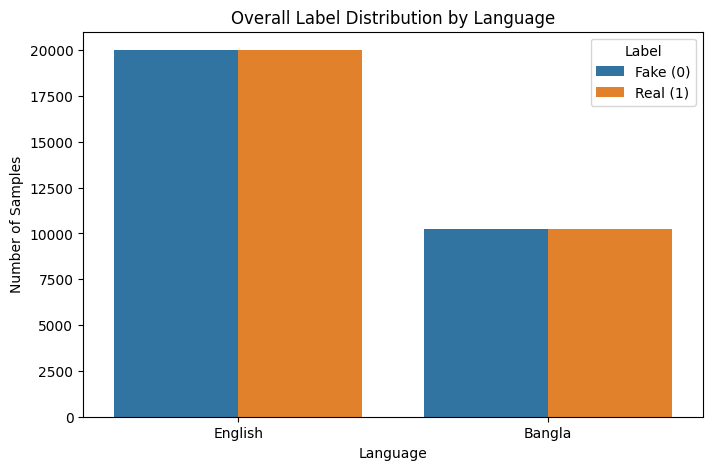

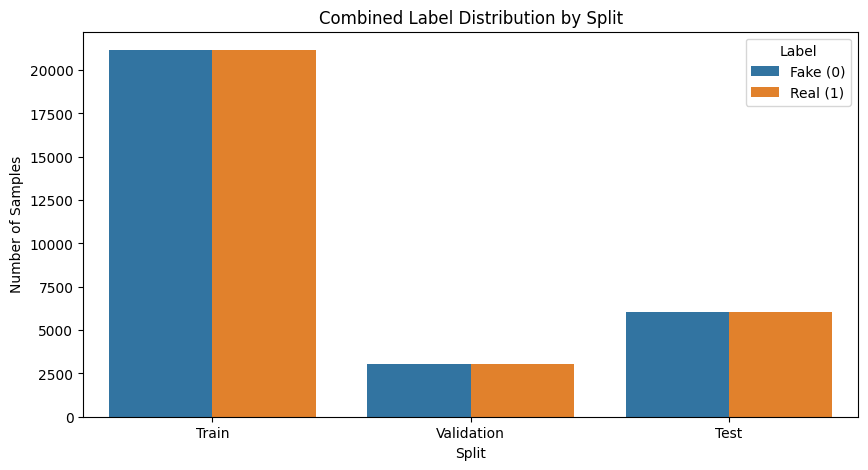

In [13]:
# Step 13: Label Distribution Visualization

label_distribution = pd.concat([
    english_train.assign(Language="English", Split="Train"),
    english_validation.assign(Language="English", Split="Validation"),
    english_test.assign(Language="English", Split="Test"),
    bangla_train.assign(Language="Bangla", Split="Train"),
    bangla_validation.assign(Language="Bangla", Split="Validation"),
    bangla_test.assign(Language="Bangla", Split="Test")
], ignore_index=True)

plt.figure(figsize=(8, 5))
sns.countplot(data=label_distribution, x="Language", hue="label")
plt.title("Overall Label Distribution by Language")
plt.xlabel("Language")
plt.ylabel("Number of Samples")
plt.legend(title="Label", labels=["Fake (0)", "Real (1)"])
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=label_distribution, x="Split", hue="label")
plt.title("Combined Label Distribution by Split")
plt.xlabel("Split")
plt.ylabel("Number of Samples")
plt.legend(title="Label", labels=["Fake (0)", "Real (1)"])
plt.show()


## Dataset Quality Control Verification

The final datasets were cleaned before upload. This section verifies that the uploaded files are still safe to use. The checks include missing values, invalid labels, empty text, duplicate text, and cross-split overlap.


In [14]:
# Step 14: Missing Value, Invalid Label, and Duplicate Check

def normalize_text_for_quality(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text

def quality_check_basic(df, name):
    normalized_text = df["text"].apply(normalize_text_for_quality)

    return {
        "Dataset": name,
        "Rows": int(df.shape[0]),
        "Missing Text": int(df["text"].isna().sum()),
        "Missing Label": int(df["label"].isna().sum()),
        "Empty Text": int((df["text"].astype(str).str.strip() == "").sum()),
        "Invalid Labels": int((~df["label"].isin([0, 1])).sum()),
        "Exact Duplicate Texts": int(df["text"].duplicated().sum()),
        "Normalized Duplicate Texts": int(normalized_text.duplicated().sum())
    }

quality_table = pd.DataFrame([
    quality_check_basic(english_train, "English Train"),
    quality_check_basic(english_validation, "English Validation"),
    quality_check_basic(english_test, "English Test"),
    quality_check_basic(bangla_train, "Bangla Train"),
    quality_check_basic(bangla_validation, "Bangla Validation"),
    quality_check_basic(bangla_test, "Bangla Test")
])

display(quality_table)

quality_problem_columns = [
    "Missing Text",
    "Missing Label",
    "Empty Text",
    "Invalid Labels",
    "Exact Duplicate Texts",
    "Normalized Duplicate Texts"
]

if (quality_table[quality_problem_columns].sum().sum() != 0):
    raise ValueError(
        "Dataset quality check found missing values, invalid labels, or duplicate text. "
        "Please inspect quality_table before continuing."
    )

print("Dataset quality check passed.")

,Dataset,Rows,Missing Text,Missing Label,Empty Text,Invalid Labels,Exact Duplicate Texts,Normalized Duplicate Texts
0,English Train,28014,0,0,0,0,0,0
1,English Validation,4002,0,0,0,0,0,0
2,English Test,8004,0,0,0,0,0,0
3,Bangla Train,14308,0,0,0,0,0,0
4,Bangla Validation,2044,0,0,0,0,0,0
5,Bangla Test,4088,0,0,0,0,0,0


Dataset quality check passed.


## Dataset Quality Control Summary

The dataset passed the main quality-control checks before model training. Each split was checked for missing text, missing labels, empty text, invalid labels, exact duplicate text, and normalized duplicate text. No missing values, invalid labels, or duplicate text records were found in the final cleaned, balanced, and quality-controlled dataset.

These checks are important because the dataset was compiled from multiple public sources. Without quality control, repeated records, inconsistent labels, or empty text values could affect model training and produce unreliable evaluation results.

## Dataset Construction Flow

To make the dataset preparation process transparent, this section summarizes how the final modeling dataset was constructed. The final files were checked for missing text, invalid labels, duplicate normalized texts, class balance, and cross-split overlap.

Because the final polished files do not contain row-level source identifiers, this table reports final dataset construction at the split level rather than at the individual-source level.

In [15]:
# Step 15: Cross-Split Exact Overlap Check

def overlap_count(df1, df2):
    return len(set(df1["text"].astype(str)) & set(df2["text"].astype(str)))

overlap_table = pd.DataFrame({
    "Language": ["English", "English", "English", "Bangla", "Bangla", "Bangla"],
    "Comparison": [
        "Train vs Validation", "Train vs Test", "Validation vs Test",
        "Train vs Validation", "Train vs Test", "Validation vs Test"
    ],
    "Exact Text Overlap": [
        overlap_count(english_train, english_validation),
        overlap_count(english_train, english_test),
        overlap_count(english_validation, english_test),
        overlap_count(bangla_train, bangla_validation),
        overlap_count(bangla_train, bangla_test),
        overlap_count(bangla_validation, bangla_test)
    ]
})

display(overlap_table)


,Language,Comparison,Exact Text Overlap
0,English,Train vs Validation,0
1,English,Train vs Test,0
2,English,Validation vs Test,0
3,Bangla,Train vs Validation,0
4,Bangla,Train vs Test,0
5,Bangla,Validation vs Test,0


In [16]:
# Step 16: Dataset Construction Flow Table

construction_flow = pd.DataFrame([
    {
        "Language": "Bangla",
        "Final file": "bangla train.csv",
        "Split": "Train",
        "Rows": len(bangla_train),
        "Fake news (0)": int((bangla_train["label"] == 0).sum()),
        "Real news (1)": int((bangla_train["label"] == 1).sum()),
        "Purpose": "Model training"
    },
    {
        "Language": "Bangla",
        "Final file": "bangla validation.csv",
        "Split": "Validation",
        "Rows": len(bangla_validation),
        "Fake news (0)": int((bangla_validation["label"] == 0).sum()),
        "Real news (1)": int((bangla_validation["label"] == 1).sum()),
        "Purpose": "Model selection and hyperparameter checking"
    },
    {
        "Language": "Bangla",
        "Final file": "bangla test.csv",
        "Split": "Test",
        "Rows": len(bangla_test),
        "Fake news (0)": int((bangla_test["label"] == 0).sum()),
        "Real news (1)": int((bangla_test["label"] == 1).sum()),
        "Purpose": "Final internal performance reporting"
    },
    {
        "Language": "English",
        "Final file": "english train.csv",
        "Split": "Train",
        "Rows": len(english_train),
        "Fake news (0)": int((english_train["label"] == 0).sum()),
        "Real news (1)": int((english_train["label"] == 1).sum()),
        "Purpose": "Model training"
    },
    {
        "Language": "English",
        "Final file": "english validation.csv",
        "Split": "Validation",
        "Rows": len(english_validation),
        "Fake news (0)": int((english_validation["label"] == 0).sum()),
        "Real news (1)": int((english_validation["label"] == 1).sum()),
        "Purpose": "Model selection and hyperparameter checking"
    },
    {
        "Language": "English",
        "Final file": "english test.csv",
        "Split": "Test",
        "Rows": len(english_test),
        "Fake news (0)": int((english_test["label"] == 0).sum()),
        "Real news (1)": int((english_test["label"] == 1).sum()),
        "Purpose": "Final internal performance reporting"
    }
])

display(construction_flow)

,Language,Final file,Split,Rows,Fake news (0),Real news (1),Purpose
0,Bangla,bangla train.csv,Train,14308,7154,7154,Model training
1,Bangla,bangla validation.csv,Validation,2044,1022,1022,Model selection and hyperparameter checking
2,Bangla,bangla test.csv,Test,4088,2044,2044,Final internal performance reporting
3,English,english train.csv,Train,28014,14007,14007,Model training
4,English,english validation.csv,Validation,4002,2001,2001,Model selection and hyperparameter checking
5,English,english test.csv,Test,8004,4002,4002,Final internal performance reporting


In [17]:
# Step 17: Cross-Split Normalized Overlap Check

def normalize_for_overlap(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

def normalized_overlap_count(df1, df2):
    set1 = set(df1["text"].astype(str).apply(normalize_for_overlap))
    set2 = set(df2["text"].astype(str).apply(normalize_for_overlap))
    return len(set1 & set2)

normalized_overlap_table = pd.DataFrame({
    "Language": ["English", "English", "English", "Bangla", "Bangla", "Bangla"],
    "Comparison": [
        "Train vs Validation", "Train vs Test", "Validation vs Test",
        "Train vs Validation", "Train vs Test", "Validation vs Test"
    ],
    "Normalized Text Overlap": [
        normalized_overlap_count(english_train, english_validation),
        normalized_overlap_count(english_train, english_test),
        normalized_overlap_count(english_validation, english_test),
        normalized_overlap_count(bangla_train, bangla_validation),
        normalized_overlap_count(bangla_train, bangla_test),
        normalized_overlap_count(bangla_validation, bangla_test)
    ]
})

display(normalized_overlap_table)

,Language,Comparison,Normalized Text Overlap
0,English,Train vs Validation,0
1,English,Train vs Test,0
2,English,Validation vs Test,0
3,Bangla,Train vs Validation,0
4,Bangla,Train vs Test,0
5,Bangla,Validation vs Test,0


## Data Leakage Prevention

Cross-split overlap checking was performed to reduce the risk of data leakage. The purpose of this step was to confirm that the same normalized text did not appear in more than one split, such as both the training and testing sets.

This is important because duplicate or overlapping records across splits can make a model appear stronger than it actually is. By checking for overlap, the final evaluation becomes more reliable because the test set better represents unseen data.

In [18]:
# Step 18: Word Count Analysis

for df in all_datasets:
    df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

word_count_summary = pd.DataFrame({
    "Dataset": [
        "English Train", "English Validation", "English Test",
        "Bangla Train", "Bangla Validation", "Bangla Test"
    ],
    "Minimum Words": [
        english_train["word_count"].min(),
        english_validation["word_count"].min(),
        english_test["word_count"].min(),
        bangla_train["word_count"].min(),
        bangla_validation["word_count"].min(),
        bangla_test["word_count"].min()
    ],
    "Mean Words": [
        round(english_train["word_count"].mean(), 2),
        round(english_validation["word_count"].mean(), 2),
        round(english_test["word_count"].mean(), 2),
        round(bangla_train["word_count"].mean(), 2),
        round(bangla_validation["word_count"].mean(), 2),
        round(bangla_test["word_count"].mean(), 2)
    ],
    "Median Words": [
        english_train["word_count"].median(),
        english_validation["word_count"].median(),
        english_test["word_count"].median(),
        bangla_train["word_count"].median(),
        bangla_validation["word_count"].median(),
        bangla_test["word_count"].median()
    ]
})

display(word_count_summary)

,Dataset,Minimum Words,Mean Words,Median Words
0,English Train,22,321.81,228.0
1,English Validation,22,310.88,228.0
2,English Test,22,314.09,228.0
3,Bangla Train,31,273.38,219.0
4,Bangla Validation,35,267.35,214.0
5,Bangla Test,30,272.37,217.0


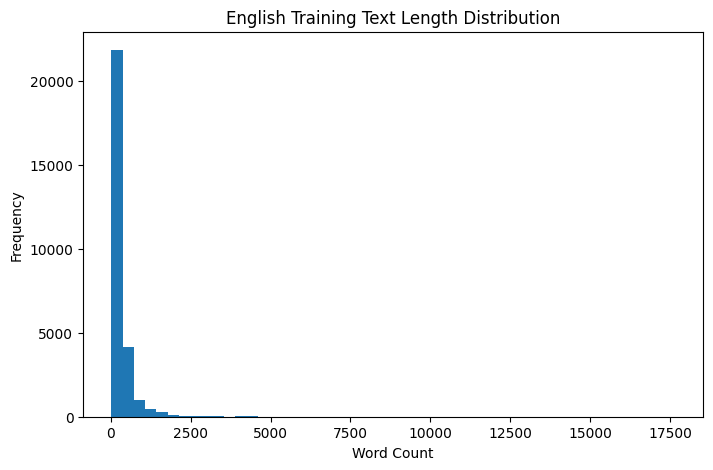

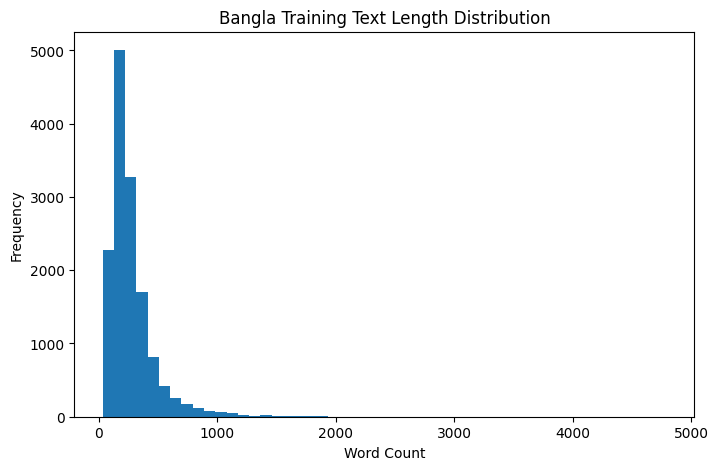

In [19]:
# Step 19: Text Length Visualization

plt.figure(figsize=(8, 5))
plt.hist(english_train["word_count"].dropna(), bins=50)
plt.title("English Training Text Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(bangla_train["word_count"].dropna(), bins=50)
plt.title("Bangla Training Text Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

## Final Text Preparation

The uploaded datasets are already cleaned. Therefore, this notebook applies only light final text preparation. This avoids damaging meaningful linguistic patterns, especially in Bangla. The same label mapping is preserved for both datasets.


In [20]:
# Step 20: Light Final Text Preparation Function

def final_text_prepare(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in all_datasets:
    df["clean_text"] = df["text"].apply(final_text_prepare)

print("Final text preparation completed.")


Final text preparation completed.


In [21]:
# Step 21: Assign Train, Validation, and Test Variables

X_eng_train = english_train["clean_text"]
y_eng_train = english_train["label"]

X_eng_val = english_validation["clean_text"]
y_eng_val = english_validation["label"]

X_eng_test = english_test["clean_text"]
y_eng_test = english_test["label"]

X_ban_train = bangla_train["clean_text"]
y_ban_train = bangla_train["label"]

X_ban_val = bangla_validation["clean_text"]
y_ban_val = bangla_validation["label"]

X_ban_test = bangla_test["clean_text"]
y_ban_test = bangla_test["label"]

print("English Train:", X_eng_train.shape, y_eng_train.shape)
print("English Validation:", X_eng_val.shape, y_eng_val.shape)
print("English Test:", X_eng_test.shape, y_eng_test.shape)

print("\nBangla Train:", X_ban_train.shape, y_ban_train.shape)
print("Bangla Validation:", X_ban_val.shape, y_ban_val.shape)
print("Bangla Test:", X_ban_test.shape, y_ban_test.shape)

English Train: (28014,) (28014,)
English Validation: (4002,) (4002,)
English Test: (8004,) (8004,)

Bangla Train: (14308,) (14308,)
Bangla Validation: (2044,) (2044,)
Bangla Test: (4088,) (4088,)


## TF-IDF Feature Extraction

TF-IDF converts text into numerical feature vectors. To prevent data leakage, the TF-IDF vectorizer is fitted only on the training set. The validation and test sets are transformed using the vectorizer fitted on the training data.

Separate TF-IDF vectorizers are used for English and Bangla because the languages have different scripts and vocabulary distributions.


## Text Representation Using TF-IDF

Each news article was treated as a document and converted into a numerical feature vector using TF-IDF. This approach represents text through term-based features and gives higher importance to terms that are frequent in a document but less frequent across the corpus.

Separate TF-IDF vectorizers were used for Bangla and English. This prevented vocabulary mixing between the two languages and allowed each language to maintain its own feature space.

In [22]:
# Step 22: Create TF-IDF Vectorizers

TFIDF_MAX_FEATURES = 20000

english_tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    lowercase=True
)

bangla_tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    lowercase=False
)

print("TF-IDF vectorizers created successfully.")


TF-IDF vectorizers created successfully.


In [23]:
# Step 23: Fit TF-IDF on Training Data and Transform Validation/Test Data

X_eng_train_tfidf = english_tfidf.fit_transform(X_eng_train)
X_eng_val_tfidf = english_tfidf.transform(X_eng_val)
X_eng_test_tfidf = english_tfidf.transform(X_eng_test)

X_ban_train_tfidf = bangla_tfidf.fit_transform(X_ban_train)
X_ban_val_tfidf = bangla_tfidf.transform(X_ban_val)
X_ban_test_tfidf = bangla_tfidf.transform(X_ban_test)

print("English TF-IDF Shapes:")
print("Train:", X_eng_train_tfidf.shape)
print("Validation:", X_eng_val_tfidf.shape)
print("Test:", X_eng_test_tfidf.shape)

print("\nBangla TF-IDF Shapes:")
print("Train:", X_ban_train_tfidf.shape)
print("Validation:", X_ban_val_tfidf.shape)
print("Test:", X_ban_test_tfidf.shape)


English TF-IDF Shapes:
Train: (28014, 20000)
Validation: (4002, 20000)
Test: (8004, 20000)

Bangla TF-IDF Shapes:
Train: (14308, 20000)
Validation: (2044, 20000)
Test: (4088, 20000)


In [24]:
# Step 24: TF-IDF Settings Table

tfidf_settings = pd.DataFrame({
    "Parameter": ["max_features", "ngram_range", "min_df", "max_df", "sublinear_tf"],
    "English Value": [TFIDF_MAX_FEATURES, "(1, 2)", 2, 0.95, True],
    "Bangla Value": [TFIDF_MAX_FEATURES, "(1, 2)", 2, 0.95, True]
})

display(tfidf_settings)


,Parameter,English Value,Bangla Value
0,max_features,20000,20000
1,ngram_range,"(1, 2)","(1, 2)"
2,min_df,2,2
3,max_df,0.95,0.95
4,sublinear_tf,True,True


## System Architecture Diagram

The following diagram presents the overall workflow of the proposed fake news detection system. The pipeline starts with cleaned Bangla and English text datasets, followed by language-specific text preparation, TF-IDF feature extraction, classical machine learning model training, and final performance evaluation.

This visual representation helps summarize the experimental design and shows how the Bangla and English fake news detection pipelines are processed separately but evaluated under the same methodological framework.

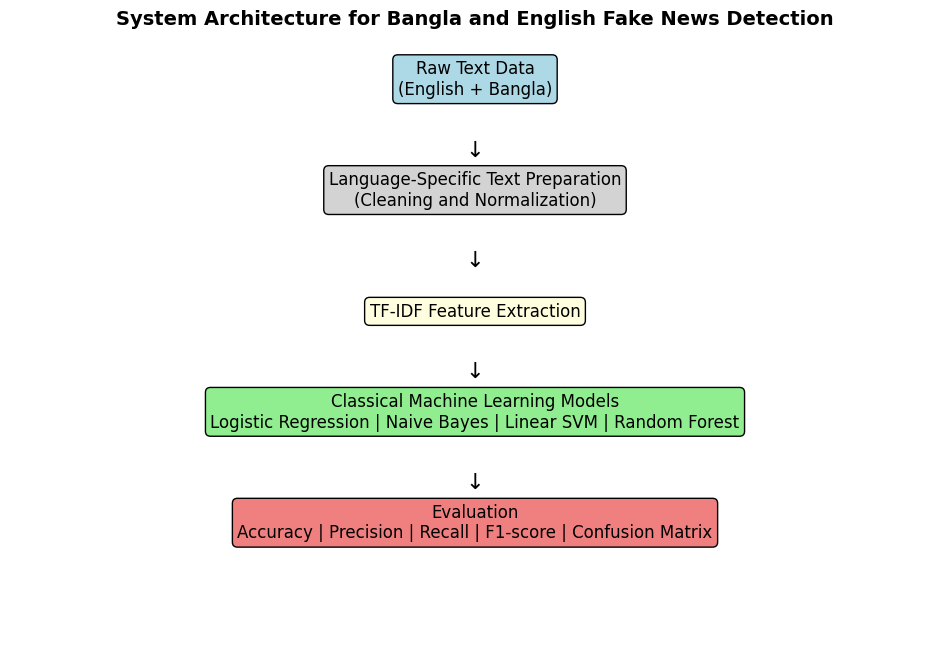

In [25]:
# Step 25: System Architecture Diagram

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Box 1
plt.text(
    0.5, 0.90,
    "Raw Text Data\n(English + Bangla)",
    ha="center",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightblue")
)

# Arrow
plt.text(0.5, 0.80, "↓", ha="center", fontsize=16)

# Box 2
plt.text(
    0.5, 0.72,
    "Language-Specific Text Preparation\n(Cleaning and Normalization)",
    ha="center",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightgray")
)

# Arrow
plt.text(0.5, 0.62, "↓", ha="center", fontsize=16)

# Box 3
plt.text(
    0.5, 0.54,
    "TF-IDF Feature Extraction",
    ha="center",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightyellow")
)

# Arrow
plt.text(0.5, 0.44, "↓", ha="center", fontsize=16)

# Box 4
plt.text(
    0.5, 0.36,
    "Classical Machine Learning Models\nLogistic Regression | Naive Bayes | Linear SVM | Random Forest",
    ha="center",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightgreen")
)

# Arrow
plt.text(0.5, 0.26, "↓", ha="center", fontsize=16)

# Box 5
plt.text(
    0.5, 0.18,
    "Evaluation\nAccuracy | Precision | Recall | F1-score | Confusion Matrix",
    ha="center",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightcoral")
)

plt.axis("off")
plt.title(
    "System Architecture for Bangla and English Fake News Detection",
    fontsize=14,
    fontweight="bold"
)

plt.show()

## Hyperparameter Tuning and Cross-Validation

To improve model reliability, Linear SVM was tuned using different values of the regularization parameter C. The best parameter was selected based on weighted F1-score. After selecting the best C value, 5-fold cross-validation was performed on the training data to examine model stability.

In [26]:
# Step 26: Hyperparameter Tuning for Linear SVM

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

# Parameter grid for Linear SVM
svm_params = {
    'C': [0.1, 1, 10]
}

# English SVM tuning
svm_grid_english = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=10000),
    svm_params,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

svm_grid_english.fit(X_eng_train_tfidf, y_eng_train)

print("Best English SVM Parameters:", svm_grid_english.best_params_)
print("Best English SVM Validation Score:", svm_grid_english.best_score_)


# Bangla SVM tuning
svm_grid_bangla = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=10000),
    svm_params,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

svm_grid_bangla.fit(X_ban_train_tfidf, y_ban_train)

print("\nBest Bangla SVM Parameters:", svm_grid_bangla.best_params_)
print("Best Bangla SVM Validation Score:", svm_grid_bangla.best_score_)

Best English SVM Parameters: {'C': 1}
Best English SVM Validation Score: 0.979545738146292

Best Bangla SVM Parameters: {'C': 1}
Best Bangla SVM Validation Score: 0.790527827730851


In [27]:
# Step 27: Best Hyperparameter Summary

best_hyperparameters = pd.DataFrame({
    "Language": ["English", "Bangla"],
    "Model": ["Linear SVM", "Linear SVM"],
    "Best Parameters": [
        svm_grid_english.best_params_,
        svm_grid_bangla.best_params_
    ],
    "Best CV F1-score": [
        svm_grid_english.best_score_,
        svm_grid_bangla.best_score_
    ]
})

display(best_hyperparameters)

,Language,Model,Best Parameters,Best CV F1-score
0,English,Linear SVM,{'C': 1},0.979546
1,Bangla,Linear SVM,{'C': 1},0.790528


In [28]:
# Step 28: Cross Validation for Linear SVM

from sklearn.model_selection import cross_val_score

# Extract best C values
best_c_english = svm_grid_english.best_params_['C']
best_c_bangla = svm_grid_bangla.best_params_['C']

# English cross-validation
english_svm_cv = LinearSVC(
    class_weight='balanced',
    C=best_c_english,
    max_iter=10000
)

english_cv_scores = cross_val_score(
    english_svm_cv,
    X_eng_train_tfidf,
    y_eng_train,
    cv=5,
    scoring='f1_weighted'
)

print("English 5-Fold CV F1 Scores:", english_cv_scores)
print("English Mean CV F1 Score:", english_cv_scores.mean())


# Bangla cross-validation
bangla_svm_cv = LinearSVC(
    class_weight='balanced',
    C=best_c_bangla,
    max_iter=10000
)

bangla_cv_scores = cross_val_score(
    bangla_svm_cv,
    X_ban_train_tfidf,
    y_ban_train,
    cv=5,
    scoring='f1_weighted'
)

print("\nBangla 5-Fold CV F1 Scores:", bangla_cv_scores)
print("Bangla Mean CV F1 Score:", bangla_cv_scores.mean())

English 5-Fold CV F1 Scores: [0.98090305 0.98268781 0.98054592 0.98286619 0.97590119]
English Mean CV F1 Score: 0.9805808339449553

Bangla 5-Fold CV F1 Scores: [0.80118796 0.80013976 0.80048622 0.79375648 0.78643486]
Bangla Mean CV F1 Score: 0.7964010564027019


In [29]:
# Step 29: Cross-Validation Summary Table

cv_summary = pd.DataFrame({
    "Language": ["English", "Bangla"],
    "Model": ["Linear SVM", "Linear SVM"],
    "Best C": [best_c_english, best_c_bangla],
    "CV Fold 1": [english_cv_scores[0], bangla_cv_scores[0]],
    "CV Fold 2": [english_cv_scores[1], bangla_cv_scores[1]],
    "CV Fold 3": [english_cv_scores[2], bangla_cv_scores[2]],
    "CV Fold 4": [english_cv_scores[3], bangla_cv_scores[3]],
    "CV Fold 5": [english_cv_scores[4], bangla_cv_scores[4]],
    "Mean CV F1-score": [english_cv_scores.mean(), bangla_cv_scores.mean()],
    "Std CV F1-score": [english_cv_scores.std(), bangla_cv_scores.std()]
})

display(cv_summary)

,Language,Model,Best C,CV Fold 1,CV Fold 2,CV Fold 3,CV Fold 4,CV Fold 5,Mean CV F1-score,Std CV F1-score
0,English,Linear SVM,1,0.980903,0.982688,0.980546,0.982866,0.975901,0.980581,0.002517
1,Bangla,Linear SVM,1,0.801188,0.800140,0.800486,0.793756,0.786435,0.796401,0.005655


## Model Training and Evaluation

Four classical machine learning models are evaluated:

1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear Support Vector Machine
4. Random Forest

Validation performance is used for model comparison and selection. The test set is used only for final evaluation.


In [30]:
# Step 30: Define Evaluation Function

def get_auc_score(model, X, y_true):
    """Calculate ROC-AUC when possible."""
    try:
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X)[:, 1]
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X)
        else:
            return np.nan
        return roc_auc_score(y_true, scores)
    except Exception:
        return np.nan


def evaluate_predictions(y_true, y_pred, model=None, X=None):
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }
    if model is not None and X is not None:
        result["ROC-AUC"] = get_auc_score(model, X, y_true)
    else:
        result["ROC-AUC"] = np.nan
    return result

print("Evaluation functions ready.")


Evaluation functions ready.


In [31]:
# Step 31: Define Model Training Function

def train_validate_test_model(model, X_train, y_train, X_val, y_val, X_test, y_test, model_name, language):
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    val_metrics = evaluate_predictions(y_val, y_val_pred, model=model, X=X_val)
    test_metrics = evaluate_predictions(y_test, y_test_pred, model=model, X=X_test)

    val_result = {
        "Language": language,
        "Model": model_name,
        "Validation Accuracy": val_metrics["Accuracy"],
        "Validation Precision": val_metrics["Precision"],
        "Validation Recall": val_metrics["Recall"],
        "Validation F1-score": val_metrics["F1-score"],
        "Validation Macro-F1": val_metrics["Macro-F1"],
        "Validation ROC-AUC": val_metrics["ROC-AUC"]
    }

    test_result = {
        "Language": language,
        "Model": model_name,
        "Accuracy": test_metrics["Accuracy"],
        "Precision": test_metrics["Precision"],
        "Recall": test_metrics["Recall"],
        "F1-score": test_metrics["F1-score"],
        "Macro-F1": test_metrics["Macro-F1"],
        "ROC-AUC": test_metrics["ROC-AUC"]
    }

    print(f"Completed: {language} - {model_name}")
    print(classification_report(y_test, y_test_pred, target_names=["Fake News", "Real News"], zero_division=0))

    return val_result, test_result, y_test_pred, model


In [32]:
# Step 32: Define Machine Learning Models

english_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(C=best_c_english, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=None, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1)
}

bangla_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(C=best_c_bangla, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=None, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1)
}

print("English Models:", list(english_models.keys()))
print("Bangla Models:", list(bangla_models.keys()))


English Models: ['Logistic Regression', 'Naive Bayes', 'Linear SVM', 'Random Forest']
Bangla Models: ['Logistic Regression', 'Naive Bayes', 'Linear SVM', 'Random Forest']


## Model Evaluation Strategy

The validation set was used for model comparison and hyperparameter selection, while the test set was reserved for final performance reporting. This separation helped reduce the risk of selecting a model based only on test-set performance.

Multiple evaluation metrics were used instead of relying only on accuracy. Accuracy measured overall correctness, while precision, recall, F1-score, macro-F1, weighted F1-score, ROC-AUC, and confusion matrices provided a broader view of classifier performance. McNemar’s test was also used to examine whether the performance differences between models were statistically meaningful.

In [33]:
# Step 33: Train and Evaluate English Models

english_validation_results = []
english_test_results = []
english_test_predictions = {}
english_trained_models = {}

for model_name, model in english_models.items():
    val_result, test_result, y_pred, trained_model = train_validate_test_model(
        model=model,
        X_train=X_eng_train_tfidf,
        y_train=y_eng_train,
        X_val=X_eng_val_tfidf,
        y_val=y_eng_val,
        X_test=X_eng_test_tfidf,
        y_test=y_eng_test,
        model_name=model_name,
        language="English"
    )

    english_validation_results.append(val_result)
    english_test_results.append(test_result)
    english_test_predictions[model_name] = y_pred
    english_trained_models[model_name] = trained_model


Completed: English - Logistic Regression
              precision    recall  f1-score   support

   Fake News       0.98      0.97      0.97      4002
   Real News       0.97      0.98      0.97      4002

    accuracy                           0.97      8004
   macro avg       0.97      0.97      0.97      8004
weighted avg       0.97      0.97      0.97      8004

Completed: English - Naive Bayes
              precision    recall  f1-score   support

   Fake News       0.94      0.94      0.94      4002
   Real News       0.94      0.94      0.94      4002

    accuracy                           0.94      8004
   macro avg       0.94      0.94      0.94      8004
weighted avg       0.94      0.94      0.94      8004

Completed: English - Linear SVM
              precision    recall  f1-score   support

   Fake News       0.98      0.98      0.98      4002
   Real News       0.98      0.98      0.98      4002

    accuracy                           0.98      8004
   macro avg       0.9

In [34]:
# Step 34: Train and Evaluate Bangla Models

bangla_validation_results = []
bangla_test_results = []
bangla_test_predictions = {}
bangla_trained_models = {}

for model_name, model in bangla_models.items():
    val_result, test_result, y_pred, trained_model = train_validate_test_model(
        model=model,
        X_train=X_ban_train_tfidf,
        y_train=y_ban_train,
        X_val=X_ban_val_tfidf,
        y_val=y_ban_val,
        X_test=X_ban_test_tfidf,
        y_test=y_ban_test,
        model_name=model_name,
        language="Bangla"
    )

    bangla_validation_results.append(val_result)
    bangla_test_results.append(test_result)
    bangla_test_predictions[model_name] = y_pred
    bangla_trained_models[model_name] = trained_model


Completed: Bangla - Logistic Regression
              precision    recall  f1-score   support

   Fake News       0.79      0.81      0.80      2044
   Real News       0.80      0.78      0.79      2044

    accuracy                           0.80      4088
   macro avg       0.80      0.80      0.80      4088
weighted avg       0.80      0.80      0.80      4088

Completed: Bangla - Naive Bayes
              precision    recall  f1-score   support

   Fake News       0.76      0.74      0.75      2044
   Real News       0.75      0.77      0.76      2044

    accuracy                           0.75      4088
   macro avg       0.75      0.75      0.75      4088
weighted avg       0.75      0.75      0.75      4088

Completed: Bangla - Linear SVM
              precision    recall  f1-score   support

   Fake News       0.78      0.80      0.79      2044
   Real News       0.80      0.77      0.78      2044

    accuracy                           0.79      4088
   macro avg       0.79  

In [35]:
# Step 35: Validation Result Table

english_validation_df = pd.DataFrame(english_validation_results)
bangla_validation_df = pd.DataFrame(bangla_validation_results)
validation_results_df = pd.concat([english_validation_df, bangla_validation_df], ignore_index=True)
validation_results_df = validation_results_df.round(4)

display(validation_results_df)


,Language,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1-score,Validation Macro-F1,Validation ROC-AUC
0,English,Logistic Regression,0.9713,0.9713,0.9713,0.9713,0.9713,0.9965
1,English,Naive Bayes,0.9373,0.9373,0.9373,0.9373,0.9373,0.9826
2,English,Linear SVM,0.9800,0.9800,0.9800,0.9800,0.9800,0.9982
3,English,Random Forest,0.9650,0.9650,0.9650,0.9650,0.9650,0.9950
4,Bangla,Logistic Regression,0.7926,0.7930,0.7926,0.7925,0.7925,0.8735
5,Bangla,Naive Bayes,0.7583,0.7584,0.7583,0.7583,0.7583,0.8272
6,Bangla,Linear SVM,0.7994,0.8000,0.7994,0.7993,0.7993,0.8777
7,Bangla,Random Forest,0.7769,0.7783,0.7769,0.7766,0.7766,0.8610


In [36]:
# Step 36: Best Model Based on Validation F1-score

best_english_validation = validation_results_df[
    validation_results_df["Language"] == "English"
].sort_values(by="Validation F1-score", ascending=False).iloc[0]

best_bangla_validation = validation_results_df[
    validation_results_df["Language"] == "Bangla"
].sort_values(by="Validation F1-score", ascending=False).iloc[0]

print("Best English Model Based on Validation F1-score:")
print(best_english_validation)

print("\nBest Bangla Model Based on Validation F1-score:")
print(best_bangla_validation)


Best English Model Based on Validation F1-score:
Language                   English
Model                   Linear SVM
Validation Accuracy           0.98
Validation Precision          0.98
Validation Recall             0.98
Validation F1-score           0.98
Validation Macro-F1           0.98
Validation ROC-AUC          0.9982
Name: 2, dtype: object

Best Bangla Model Based on Validation F1-score:
Language                    Bangla
Model                   Linear SVM
Validation Accuracy         0.7994
Validation Precision           0.8
Validation Recall           0.7994
Validation F1-score         0.7993
Validation Macro-F1         0.7993
Validation ROC-AUC          0.8777
Name: 6, dtype: object


In [37]:
# Step 37: Final Test Result Table

english_results_df = pd.DataFrame(english_test_results)
bangla_results_df = pd.DataFrame(bangla_test_results)

final_results_df = pd.concat([english_results_df, bangla_results_df], ignore_index=True)
final_results_df = final_results_df.round(4)

display(final_results_df)


,Language,Model,Accuracy,Precision,Recall,F1-score,Macro-F1,ROC-AUC
0,English,Logistic Regression,0.9735,0.9735,0.9735,0.9735,0.9735,0.9962
1,English,Naive Bayes,0.9393,0.9393,0.9393,0.9393,0.9393,0.9837
2,English,Linear SVM,0.9818,0.9818,0.9818,0.9818,0.9818,0.9978
3,English,Random Forest,0.9654,0.9654,0.9654,0.9654,0.9654,0.9947
4,Bangla,Logistic Regression,0.7967,0.7969,0.7967,0.7967,0.7967,0.8781
5,Bangla,Naive Bayes,0.7527,0.7529,0.7527,0.7526,0.7526,0.8246
6,Bangla,Linear SVM,0.7874,0.7877,0.7874,0.7874,0.7874,0.8768
7,Bangla,Random Forest,0.7789,0.7791,0.7789,0.7788,0.7788,0.8603


## Validation-Test Consistency Note

The validation and final test performances were compared to assess whether the selected models showed signs of overfitting. Similar validation and test scores suggest that the models generalized consistently across the held-out test sets. Large differences between validation and test results would indicate possible overfitting or dataset distribution differences.

## Final Model Summary

The following summary table presents the final test performance of all evaluated models for both English and Bangla datasets. The table compares key evaluation metrics, including accuracy, F1-score, macro-F1, and ROC-AUC, across languages and models. This format helps identify overall performance differences between classifiers and supports model comparison for the final discussion.

In [38]:
# Step 38: Final Summary Table

summary_table = final_results_df.pivot(
    index="Model",
    columns="Language",
    values=["Accuracy", "F1-score", "Macro-F1", "ROC-AUC"]
)

display(summary_table)

Accuracy         F1-score         Macro-F1          \
Language              Bangla English   Bangla English   Bangla English   
Model                                                                    
Linear SVM            0.7874  0.9818   0.7874  0.9818   0.7874  0.9818   
Logistic Regression   0.7967  0.9735   0.7967  0.9735   0.7967  0.9735   
Naive Bayes           0.7527  0.9393   0.7526  0.9393   0.7526  0.9393   
Random Forest         0.7789  0.9654   0.7788  0.9654   0.7788  0.9654   

                    ROC-AUC          
Language             Bangla English  
Model                                
Linear SVM           0.8768  0.9978  
Logistic Regression  0.8781  0.9962  
Naive Bayes          0.8246  0.9837  
Random Forest        0.8603  0.9947

In [39]:
# Step 39: Final Test Results for Validation-Selected Models

best_english_validation_model = best_english_validation["Model"]
best_bangla_validation_model = best_bangla_validation["Model"]

best_english_test = final_results_df[
    (final_results_df["Language"] == "English") &
    (final_results_df["Model"] == best_english_validation_model)
].iloc[0]

best_bangla_test = final_results_df[
    (final_results_df["Language"] == "Bangla") &
    (final_results_df["Model"] == best_bangla_validation_model)
].iloc[0]

print("Final English Test Result for Validation-Selected Model:")
print(best_english_test)

print("\nFinal Bangla Test Result for Validation-Selected Model:")
print(best_bangla_test)

Final English Test Result for Validation-Selected Model:
Language        English
Model        Linear SVM
Accuracy         0.9818
Precision        0.9818
Recall           0.9818
F1-score         0.9818
Macro-F1         0.9818
ROC-AUC          0.9978
Name: 2, dtype: object

Final Bangla Test Result for Validation-Selected Model:
Language         Bangla
Model        Linear SVM
Accuracy         0.7874
Precision        0.7877
Recall           0.7874
F1-score         0.7874
Macro-F1         0.7874
ROC-AUC          0.8768
Name: 6, dtype: object


## Per-Class Performance Analysis

In addition to weighted average scores, per-class precision, recall, and F1-score are reported for fake news and real news separately. This is important because fake-news detection should not only achieve high overall accuracy but should also correctly identify fake news samples.

In [40]:
# Step 40: Per-Class Performance for Validation-Selected Best Models

from sklearn.metrics import classification_report

def per_class_report_table(y_true, y_pred, language, model_name):
    report = classification_report(
        y_true,
        y_pred,
        target_names=["Fake News (0)", "Real News (1)"],
        output_dict=True,
        zero_division=0
    )

    rows = []
    for class_name in ["Fake News (0)", "Real News (1)"]:
        rows.append({
            "Language": language,
            "Model": model_name,
            "Class": class_name,
            "Precision": report[class_name]["precision"],
            "Recall": report[class_name]["recall"],
            "F1-score": report[class_name]["f1-score"],
            "Support": int(report[class_name]["support"])
        })

    return pd.DataFrame(rows)

english_per_class = per_class_report_table(
    y_true=y_eng_test,
    y_pred=english_test_predictions[best_english_validation_model],
    language="English",
    model_name=best_english_validation_model
)

bangla_per_class = per_class_report_table(
    y_true=y_ban_test,
    y_pred=bangla_test_predictions[best_bangla_validation_model],
    language="Bangla",
    model_name=best_bangla_validation_model
)

per_class_performance = pd.concat([english_per_class, bangla_per_class], ignore_index=True)
per_class_performance = per_class_performance.round(4)

display(per_class_performance)

,Language,Model,Class,Precision,Recall,F1-score,Support
0,English,Linear SVM,Fake News (0),0.9832,0.9803,0.9817,4002
1,English,Linear SVM,Real News (1),0.9803,0.9833,0.9818,4002
2,Bangla,Linear SVM,Fake News (0),0.7783,0.8038,0.7909,2044
3,Bangla,Linear SVM,Real News (1),0.7972,0.7710,0.7839,2044


## External Test-Set Evaluation

To examine model generalization beyond the internal test split, the validation-selected best English and Bangla models were evaluated on independent external evaluation datasets.

The English external file is `external evaluation of English.csv`, which was prepared from the Misinformation & Fake News text dataset 79K. The Bangla external file is `external evaluation of Bangla.csv`, which was prepared from MultiBanFakeDetect 2024 and `cleanbn_fakenews.csv`.

Both external evaluation files follow the notebook label mapping: `0 = fake news` and `1 = real news`. Before model evaluation, the external files are checked for binary labels, class balance, missing text, duplicate normalized text, and exact overlap with the internal train, validation, and test sets.

The external evaluation results are reported as an additional generalization check and should not replace the internal test-set results.

In [41]:
# Step 41: Check Uploaded External Evaluation Files Before Model Evaluation

import os
import re
import zipfile
import pandas as pd

def normalize_external_eval_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


def external_name_is_allowed(name):
    name_lower = os.path.basename(name).lower().strip()

    allowed_names = [
        "external evaluation of bangla.csv",
        "external evaluation of english.csv"
    ]

    return name_lower in allowed_names


def find_external_evaluation_records(root_dir="/kaggle/input"):
    records = []

    for root, dirs, files in os.walk(root_dir):
        for file in files:
            file_path = os.path.join(root, file)
            file_lower = file.lower().strip()

            # Case 1: CSV files uploaded directly
            if file_lower.endswith(".csv") and external_name_is_allowed(file):
                records.append({
                    "path": file_path,
                    "zip_member": None,
                    "display_name": file
                })

            # Case 2: CSV files uploaded inside a ZIP file
            elif file_lower.endswith(".zip"):
                try:
                    with zipfile.ZipFile(file_path, "r") as z:
                        for member in z.namelist():
                            member_base = os.path.basename(member)

                            if external_name_is_allowed(member_base):
                                records.append({
                                    "path": file_path,
                                    "zip_member": member,
                                    "display_name": member_base
                                })

                except Exception as e:
                    print(f"Could not inspect ZIP file {file_path}: {e}")

    return records


def read_external_record(record):
    if record["zip_member"] is None:
        return pd.read_csv(record["path"])

    with zipfile.ZipFile(record["path"], "r") as z:
        with z.open(record["zip_member"]) as f:
            return pd.read_csv(f)


external_eval_records = find_external_evaluation_records("/kaggle/input")

print("Detected external evaluation files:")

if len(external_eval_records) == 0:
    print("No external evaluation files were detected.")
    print("Please upload these two files:")
    print("1. external evaluation of Bangla.csv")
    print("2. external evaluation of English.csv")

for record in external_eval_records:
    if record["zip_member"] is None:
        print(record["path"])
    else:
        print(record["path"], "::", record["zip_member"])


external_file_check_rows = []

for record in external_eval_records:
    df = read_external_record(record)
    file_name = record["display_name"].lower().strip()

    if {"headline", "description", "label"}.issubset(df.columns):
        combined_text = df[["headline", "description"]].fillna("").astype(str).agg(" ".join, axis=1)
        detected_language = "Bangla"
        detected_type = "headline + description + label"

    elif {"text", "label"}.issubset(df.columns):
        combined_text = df["text"].fillna("").astype(str)
        detected_language = "English"
        detected_type = "text + label"

    elif {"title", "text", "label"}.issubset(df.columns):
        combined_text = df[["title", "text"]].fillna("").astype(str).agg(" ".join, axis=1)
        detected_language = "English"
        detected_type = "title + text + label"

    else:
        external_file_check_rows.append({
            "File": record["display_name"],
            "Detected language": "Unknown",
            "Detected type": "Unsupported",
            "Rows": len(df),
            "Valid binary labels": None,
            "Fake 0": None,
            "Real 1": None,
            "Missing/empty text": None,
            "Duplicate normalized text": None,
            "Balanced": None,
            "Decision": "Do not use"
        })
        continue

    normalized_text = combined_text.apply(normalize_external_eval_text)

    valid_label_count = int(df["label"].isin([0, 1]).sum())
    fake_count = int((df["label"] == 0).sum())
    real_count = int((df["label"] == 1).sum())
    missing_empty_text = int((normalized_text == "").sum())
    duplicate_count = int(normalized_text.duplicated().sum())

    if file_name == "external evaluation of english.csv":
        decision = "Use as independent English external evaluation"
    elif file_name == "external evaluation of bangla.csv":
        decision = "Use as independent Bangla external evaluation"
    else:
        decision = "Use with caution"

    external_file_check_rows.append({
        "File": record["display_name"],
        "Detected language": detected_language,
        "Detected type": detected_type,
        "Rows": len(df),
        "Valid binary labels": valid_label_count,
        "Fake 0": fake_count,
        "Real 1": real_count,
        "Missing/empty text": missing_empty_text,
        "Duplicate normalized text": duplicate_count,
        "Balanced": fake_count == real_count,
        "Decision": decision
    })


external_file_check_df = pd.DataFrame(external_file_check_rows)

display(external_file_check_df)

external_file_check_df.to_csv("external_evaluation_file_check.csv", index=False)

Detected external evaluation files:
/kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/external evaluation of Bangla.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/external evaluation of English.csv


,File,Detected language,Detected type,Rows,Valid binary labels,Fake 0,Real 1,Missing/empty text,Duplicate normalized text,Balanced,Decision
0,external evaluation of Bangla.csv,Bangla,headline + description + label,18150,18150,9075,9075,0,0,True,Use as independent Bangla external evaluation
1,external evaluation of English.csv,English,text + label,68002,68002,34001,34001,0,0,True,Use as independent English external evaluation


In [42]:
# Step 42: Publication-Safe External Test-Set Evaluation

import os
import re
import zipfile
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def normalize_text_for_overlap(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


def external_name_is_allowed(name):
    name_lower = os.path.basename(name).lower().strip()

    allowed_names = [
        "external evaluation of bangla.csv",
        "external evaluation of english.csv"
    ]

    return name_lower in allowed_names


def find_external_evaluation_records(root_dir="/kaggle/input"):
    records = []

    for root, dirs, files in os.walk(root_dir):
        for file in files:
            file_path = os.path.join(root, file)
            file_lower = file.lower().strip()

            # Case 1: CSV files uploaded directly
            if file_lower.endswith(".csv") and external_name_is_allowed(file):
                records.append({
                    "path": file_path,
                    "zip_member": None,
                    "display_name": file
                })

            # Case 2: CSV files uploaded inside a ZIP file
            elif file_lower.endswith(".zip"):
                try:
                    with zipfile.ZipFile(file_path, "r") as z:
                        for member in z.namelist():
                            member_base = os.path.basename(member)

                            if external_name_is_allowed(member_base):
                                records.append({
                                    "path": file_path,
                                    "zip_member": member,
                                    "display_name": member_base
                                })

                except Exception as e:
                    print(f"Could not inspect ZIP file {file_path}: {e}")

    return records


def read_external_record(record):
    if record["zip_member"] is None:
        return pd.read_csv(record["path"])

    with zipfile.ZipFile(record["path"], "r") as z:
        with z.open(record["zip_member"]) as f:
            return pd.read_csv(f)


def standardize_external_dataset(df, record):
    df = df.copy()
    file_lower = record["display_name"].lower().strip()

    if file_lower == "external evaluation of bangla.csv":
        if not {"headline", "description", "label"}.issubset(df.columns):
            raise ValueError(
                "Bangla external evaluation file must contain headline, description, and label columns."
            )

        df["text"] = df[["headline", "description"]].fillna("").astype(str).agg(" ".join, axis=1)
        df["label"] = df["label"].astype(int)
        df["language"] = "Bangla"
        df["external_dataset"] = "Independent Bangla external evaluation: external evaluation of Bangla"

    elif file_lower == "external evaluation of english.csv":
        if not {"text", "label"}.issubset(df.columns):
            raise ValueError(
                "English external evaluation file must contain text and label columns."
            )

        df["text"] = df["text"].astype(str)
        df["label"] = df["label"].astype(int)
        df["language"] = "English"
        df["external_dataset"] = "Independent English external evaluation: external evaluation of English"

    else:
        raise ValueError("Unknown external evaluation file.")

    df = df[["text", "label", "language", "external_dataset"]].copy()
    df["text"] = df["text"].astype(str).str.strip()
    df = df[df["text"] != ""]
    df = df[df["label"].isin([0, 1])]

    if record["zip_member"] is None:
        df["source_file"] = os.path.basename(record["path"])
    else:
        df["source_file"] = os.path.basename(record["path"]) + "::" + record["zip_member"]

    return df.reset_index(drop=True)


if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42


# Internal normalized text sets for leakage control
internal_bangla_texts = set(
    pd.concat([bangla_train["text"], bangla_validation["text"], bangla_test["text"]])
    .apply(normalize_text_for_overlap)
)

internal_english_texts = set(
    pd.concat([english_train["text"], english_validation["text"], english_test["text"]])
    .apply(normalize_text_for_overlap)
)


external_records = find_external_evaluation_records("/kaggle/input")

print("Detected external evaluation files:")

if len(external_records) == 0:
    print("No external evaluation files were detected.")
    print("Please upload these two files:")
    print("1. external evaluation of Bangla.csv")
    print("2. external evaluation of English.csv")

for record in external_records:
    if record["zip_member"] is None:
        print(record["path"])
    else:
        print(record["path"], "::", record["zip_member"])


external_dataset_details = []
external_results = []

for record in external_records:
    try:
        raw_df = read_external_record(record)
        external_df = standardize_external_dataset(raw_df, record)

        language = external_df["language"].iloc[0]
        external_dataset_name = external_df["external_dataset"].iloc[0]

        # Remove duplicate normalized text inside the external file
        external_df["normalized_text"] = external_df["text"].apply(normalize_text_for_overlap)

        before_external_duplicate_removal = len(external_df)
        external_df = external_df.drop_duplicates(subset=["normalized_text"]).copy()
        duplicate_rows_removed = before_external_duplicate_removal - len(external_df)

        if language == "Bangla":
            internal_texts = internal_bangla_texts
            vectorizer = bangla_tfidf
            trained_models = bangla_trained_models
            best_model = best_bangla_validation_model

        elif language == "English":
            internal_texts = internal_english_texts
            vectorizer = english_tfidf
            trained_models = english_trained_models
            best_model = best_english_validation_model

        else:
            print(f"Skipped {external_dataset_name}: unknown language.")
            continue

        # Remove exact overlap with internal train/validation/test files
        overlap_count = int(external_df["normalized_text"].isin(internal_texts).sum())

        external_clean = external_df[
            ~external_df["normalized_text"].isin(internal_texts)
        ].copy()

        if len(external_clean) == 0:
            print(f"Skipped {external_dataset_name}: all rows overlapped with internal data.")
            continue

        if external_clean["label"].nunique() < 2:
            print(f"Skipped {external_dataset_name}: only one class remained after overlap removal.")
            continue

        # Rebalance after overlap removal
        external_min_count = external_clean["label"].value_counts().min()

        external_balanced = (
            external_clean
            .groupby("label", group_keys=False)
            .sample(n=external_min_count, random_state=RANDOM_STATE)
            .sample(frac=1, random_state=RANDOM_STATE)
            .reset_index(drop=True)
        )

        fake_count_used = int((external_balanced["label"] == 0).sum())
        real_count_used = int((external_balanced["label"] == 1).sum())

        external_dataset_details.append({
            "Language": language,
            "External dataset": external_dataset_name,
            "Source file": external_balanced["source_file"].iloc[0],
            "Original rows loaded": len(raw_df),
            "Rows after standardization": before_external_duplicate_removal,
            "Duplicate rows removed inside external file": int(duplicate_rows_removed),
            "Rows overlapping internal train/validation/test removed": int(overlap_count),
            "Rows used after balancing": len(external_balanced),
            "Fake 0 used": fake_count_used,
            "Real 1 used": real_count_used,
            "Balanced after overlap removal": fake_count_used == real_count_used
        })

        X_external = vectorizer.transform(external_balanced["text"])
        y_external = external_balanced["label"]

        y_external_pred = trained_models[best_model].predict(X_external)

        external_results.append({
            "Language": language,
            "External dataset": external_dataset_name,
            "Source file": external_balanced["source_file"].iloc[0],
            "Model": best_model,
            "Samples used": len(external_balanced),
            "Fake 0 used": fake_count_used,
            "Real 1 used": real_count_used,
            "Accuracy": accuracy_score(y_external, y_external_pred),
            "Precision": precision_score(y_external, y_external_pred, average="weighted", zero_division=0),
            "Recall": recall_score(y_external, y_external_pred, average="weighted", zero_division=0),
            "F1-score": f1_score(y_external, y_external_pred, average="weighted", zero_division=0),
            "Macro-F1": f1_score(y_external, y_external_pred, average="macro", zero_division=0)
        })

    except Exception as e:
        print(f"Could not process {record['display_name']}: {e}")


external_dataset_details_df = pd.DataFrame(external_dataset_details)
external_results_df = pd.DataFrame(external_results)

if len(external_dataset_details_df) > 0:
    display(external_dataset_details_df)
    external_dataset_details_df.to_csv("external_dataset_details.csv", index=False)

if len(external_results_df) > 0:
    external_results_df = external_results_df.round(4)
    display(external_results_df)
    external_results_df.to_csv("external_test_results.csv", index=False)
else:
    print("No valid non-overlapping external evaluation result was produced.")

Detected external evaluation files:
/kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/external evaluation of Bangla.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-in-english-and-bangla-dataset/external evaluation of English.csv


,Language,External dataset,Source file,Original rows loaded,Rows after standardization,Duplicate rows removed inside external file,Rows overlapping internal train/validation/test removed,Rows used after balancing,Fake 0 used,Real 1 used,Balanced after overlap removal
0,Bangla,Independent Bangla external evaluation: external evaluation of Bangla,external evaluation of Bangla.csv,18150,18150,0,0,18150,9075,9075,True
1,English,Independent English external evaluation: external evaluation of English,external evaluation of English.csv,68002,68002,0,0,68002,34001,34001,True


,Language,External dataset,Source file,Model,Samples used,Fake 0 used,Real 1 used,Accuracy,Precision,Recall,F1-score,Macro-F1
0,Bangla,Independent Bangla external evaluation: external evaluation of Bangla,external evaluation of Bangla.csv,Linear SVM,18150,9075,9075,0.6369,0.6370,0.6369,0.6369,0.6369
1,English,Independent English external evaluation: external evaluation of English,external evaluation of English.csv,Linear SVM,68002,34001,34001,0.8287,0.8298,0.8287,0.8286,0.8286


## External Test-Set Label Mapping and Leakage Control

External evaluation was performed only after standardizing label mappings and checking overlap with the internal training, validation, and test sets. This step is necessary because different public datasets may use different label conventions.

The consistent label mapping in this notebook is `0 = fake news` and `1 = real news`. The English external evaluation file, `external evaluation of English.csv`, follows this mapping after assigning the original TRUE source file as real news and the FAKE/misinformation source file as fake news. The Bangla external evaluation file, `external evaluation of Bangla.csv`, also follows this mapping after remapping MultiBanFakeDetect labels and preserving the existing binary labels from `cleanbn_fakenews.csv`.

External samples that exactly overlapped with internal Bangla or English samples after text normalization were removed before evaluation to reduce the risk of data leakage. After overlap removal, the external evaluation sets were rebalanced so that fake and real samples remained equal. The external evaluation results should therefore be interpreted as an additional generalization check rather than as a replacement for the internal test-set results.

In [43]:
# Step 43: Save External Test Dataset Details

if "external_dataset_details_df" in globals() and len(external_dataset_details_df) > 0:
    external_dataset_details_df.to_csv("external_dataset_details.csv", index=False)
    display(external_dataset_details_df)

if "external_results_df" in globals() and len(external_results_df) > 0:
    external_results_df.to_csv("external_test_results.csv", index=False)
    display(external_results_df)

,Language,External dataset,Source file,Original rows loaded,Rows after standardization,Duplicate rows removed inside external file,Rows overlapping internal train/validation/test removed,Rows used after balancing,Fake 0 used,Real 1 used,Balanced after overlap removal
0,Bangla,Independent Bangla external evaluation: external evaluation of Bangla,external evaluation of Bangla.csv,18150,18150,0,0,18150,9075,9075,True
1,English,Independent English external evaluation: external evaluation of English,external evaluation of English.csv,68002,68002,0,0,68002,34001,34001,True


,Language,External dataset,Source file,Model,Samples used,Fake 0 used,Real 1 used,Accuracy,Precision,Recall,F1-score,Macro-F1
0,Bangla,Independent Bangla external evaluation: external evaluation of Bangla,external evaluation of Bangla.csv,Linear SVM,18150,9075,9075,0.6369,0.6370,0.6369,0.6369,0.6369
1,English,Independent English external evaluation: external evaluation of English,external evaluation of English.csv,Linear SVM,68002,34001,34001,0.8287,0.8298,0.8287,0.8286,0.8286


## Bias-Variance and Generalization Analysis

To examine whether the trained models suffer from underfitting or overfitting, the training, validation, and test performances were compared. A model may show high variance if it performs very well on the training set but substantially worse on the validation or test sets. A model may show high bias if performance is consistently low across training, validation, and test sets.

In this study, weighted F1-score was used as the main diagnostic metric because the task is a binary classification problem and F1-score balances precision and recall. This analysis helps evaluate whether the models generalize consistently beyond the training data.

In [44]:
# Step 44: Train-Validation-Test Performance Gap Analysis

def compute_split_metrics(model, X_train, y_train, X_val, y_val, X_test, y_test, language, model_name):
    """
    Computes train, validation, and test metrics for generalization analysis.
    This helps identify possible underfitting or overfitting.
    """

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    train_f1 = f1_score(y_train, y_train_pred, average="weighted", zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_val_gap = train_f1 - val_f1
    train_test_gap = train_f1 - test_f1
    val_test_gap = val_f1 - test_f1

    if train_f1 < 0.70 and val_f1 < 0.70 and test_f1 < 0.70:
        diagnosis = "Possible high bias / underfitting"
    elif train_test_gap > 0.05:
        diagnosis = "Possible high variance / overfitting"
    elif abs(val_test_gap) > 0.05:
        diagnosis = "Possible validation-test distribution difference"
    else:
        diagnosis = "Good generalization"

    return {
        "Language": language,
        "Model": model_name,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Test Accuracy": test_acc,
        "Train F1-score": train_f1,
        "Validation F1-score": val_f1,
        "Test F1-score": test_f1,
        "Train-Validation F1 Gap": train_val_gap,
        "Train-Test F1 Gap": train_test_gap,
        "Validation-Test F1 Gap": val_test_gap,
        "Generalization Diagnosis": diagnosis
    }


bias_variance_results = []

# English models
for model_name, trained_model in english_trained_models.items():
    bias_variance_results.append(
        compute_split_metrics(
            model=trained_model,
            X_train=X_eng_train_tfidf,
            y_train=y_eng_train,
            X_val=X_eng_val_tfidf,
            y_val=y_eng_val,
            X_test=X_eng_test_tfidf,
            y_test=y_eng_test,
            language="English",
            model_name=model_name
        )
    )

# Bangla models
for model_name, trained_model in bangla_trained_models.items():
    bias_variance_results.append(
        compute_split_metrics(
            model=trained_model,
            X_train=X_ban_train_tfidf,
            y_train=y_ban_train,
            X_val=X_ban_val_tfidf,
            y_val=y_ban_val,
            X_test=X_ban_test_tfidf,
            y_test=y_ban_test,
            language="Bangla",
            model_name=model_name
        )
    )

bias_variance_summary = pd.DataFrame(bias_variance_results)
bias_variance_summary = bias_variance_summary.round(4)

display(bias_variance_summary)

,Language,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train F1-score,Validation F1-score,Test F1-score,Train-Validation F1 Gap,Train-Test F1 Gap,Validation-Test F1 Gap,Generalization Diagnosis
0,English,Logistic Regression,0.9829,0.9713,0.9735,0.9829,0.9713,0.9735,0.0117,0.0094,-0.0022,Good generalization
1,English,Naive Bayes,0.9412,0.9373,0.9393,0.9412,0.9373,0.9393,0.0040,0.0020,-0.0020,Good generalization
2,English,Linear SVM,0.9996,0.9800,0.9818,0.9996,0.9800,0.9818,0.0196,0.0178,-0.0017,Good generalization
3,English,Random Forest,1.0000,0.9650,0.9654,1.0000,0.9650,0.9654,0.0350,0.0346,-0.0004,Good generalization
4,Bangla,Logistic Regression,0.8766,0.7926,0.7967,0.8766,0.7925,0.7967,0.0841,0.0799,-0.0042,Possible high variance / overfitting
5,Bangla,Naive Bayes,0.7812,0.7583,0.7527,0.7812,0.7583,0.7526,0.0229,0.0286,0.0057,Good generalization
6,Bangla,Linear SVM,0.9842,0.7994,0.7874,0.9842,0.7993,0.7874,0.1849,0.1968,0.0120,Possible high variance / overfitting
7,Bangla,Random Forest,0.9996,0.7769,0.7789,0.9996,0.7766,0.7788,0.2229,0.2208,-0.0022,Possible high variance / overfitting


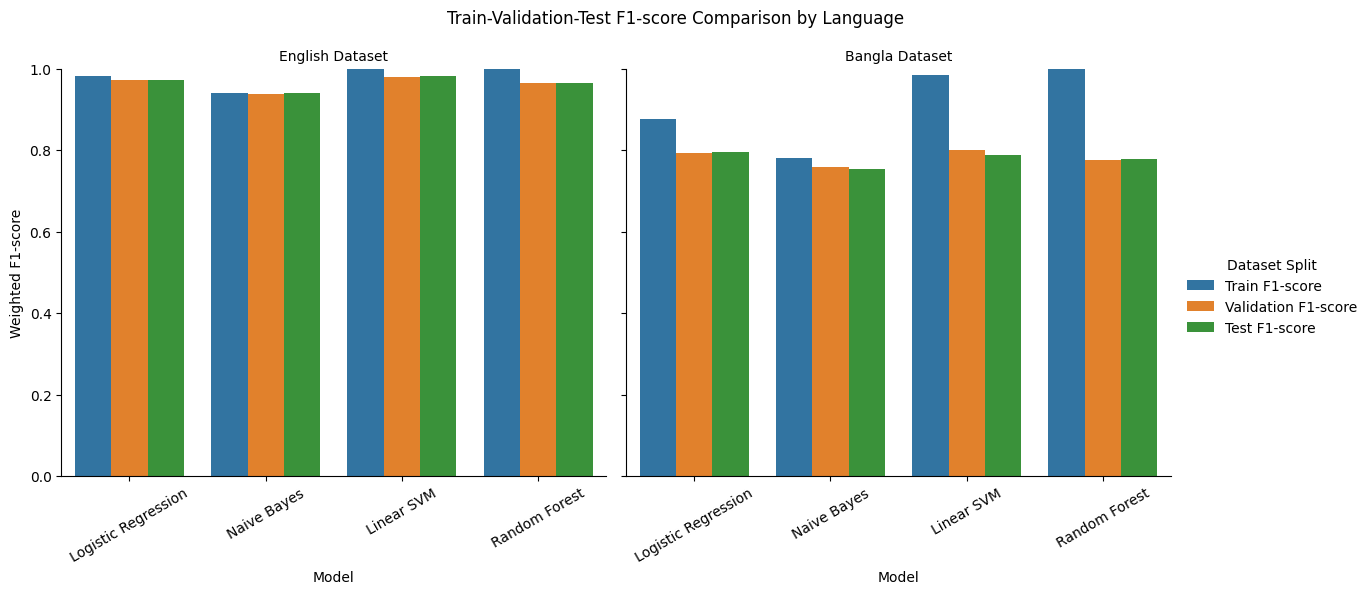

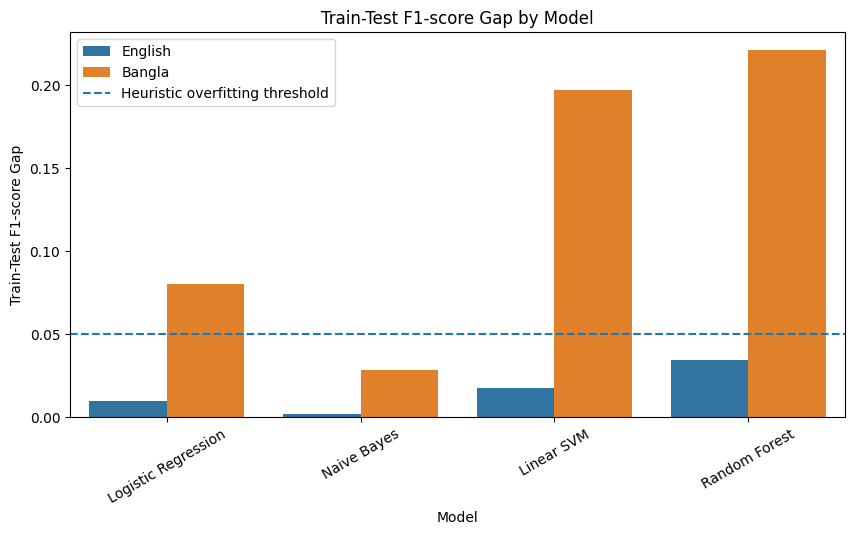

In [45]:
# Step 45: Visualize Bias-Variance / Generalization Gap

bias_variance_plot_df = bias_variance_summary.melt(
    id_vars=["Language", "Model"],
    value_vars=["Train F1-score", "Validation F1-score", "Test F1-score"],
    var_name="Dataset Split",
    value_name="Weighted F1-score"
)

# Separate train-validation-test comparison by language
g = sns.catplot(
    data=bias_variance_plot_df,
    x="Model",
    y="Weighted F1-score",
    hue="Dataset Split",
    col="Language",
    kind="bar",
    height=5,
    aspect=1.2
)

g.set_titles("{col_name} Dataset")
g.set_axis_labels("Model", "Weighted F1-score")
g.set(ylim=(0, 1))

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Train-Validation-Test F1-score Comparison by Language", y=1.05)
plt.show()


# Train-test F1-score gap by model and language
plt.figure(figsize=(10, 5))
sns.barplot(
    data=bias_variance_summary,
    x="Model",
    y="Train-Test F1 Gap",
    hue="Language"
)

plt.title("Train-Test F1-score Gap by Model")
plt.xlabel("Model")
plt.ylabel("Train-Test F1-score Gap")
plt.xticks(rotation=30)
plt.axhline(0.05, linestyle="--", label="Heuristic overfitting threshold")
plt.legend()
plt.show()

## Bias-Variance Interpretation

The bias-variance analysis shows that the English models generally achieved strong and stable performance across the training, validation, and test sets. Linear SVM achieved the highest English test performance, while the train-test gap remained small enough to indicate good generalization.

For Bangla, the results show a more challenging pattern. Logistic Regression and Linear SVM achieved the strongest Bangla validation and test performance, but both models showed a moderate train-test F1-score gap. This suggests mild high variance, meaning that the models learned some training-specific TF-IDF patterns. However, the validation-test gap remained small, indicating that the selected models still generalized consistently from validation to test data.

Random Forest showed the clearest overfitting pattern, especially for Bangla, where training performance was almost perfect but validation and test performance were much lower. This suggests that Random Forest memorized training-specific features and was less suitable for this high-dimensional TF-IDF text classification task.

Overall, Linear SVM remained the best-performing and most reliable model across both languages. The bias-variance analysis supports the final model selection while also showing that Bangla fake news detection remains more difficult than English due to linguistic variation, morphology, informal writing, and source-level diversity.

## Random Forest Overfitting Note

The bias–variance analysis showed that Random Forest exhibited the clearest overfitting behavior, especially on the Bangla dataset. For Bangla, the Random Forest model achieved almost perfect training performance, but its validation and test F1-scores were substantially lower. This indicates that the model learned training-specific TF-IDF patterns rather than generalizable decision rules.

This behavior is expected in high-dimensional sparse text classification tasks. TF-IDF representations contain thousands of unigram and bigram features, many of which may occur rarely. Tree-based ensemble models such as Random Forest can split on these sparse and dataset-specific features, which may lead to memorization of the training data. In contrast, linear models such as Logistic Regression and Linear SVM often generalize better in sparse text classification because they learn global feature weights rather than highly specific tree splits.

Although Random Forest was included as a baseline classifier, it was not selected as the final model because of its larger train-test performance gap. Linear SVM was selected as the most reliable model because it achieved the strongest overall test performance while maintaining a small validation-test gap. Therefore, the Random Forest result strengthens the analysis by showing that higher training performance does not necessarily indicate better generalization.

Future work may reduce Random Forest overfitting by using stronger regularization, such as limiting tree depth, increasing the minimum number of samples required for leaf nodes, restricting the number of features considered at each split, or reducing the TF-IDF feature space. However, in this study, the original Random Forest result was retained as a baseline to preserve a fair comparison across classical machine learning models.


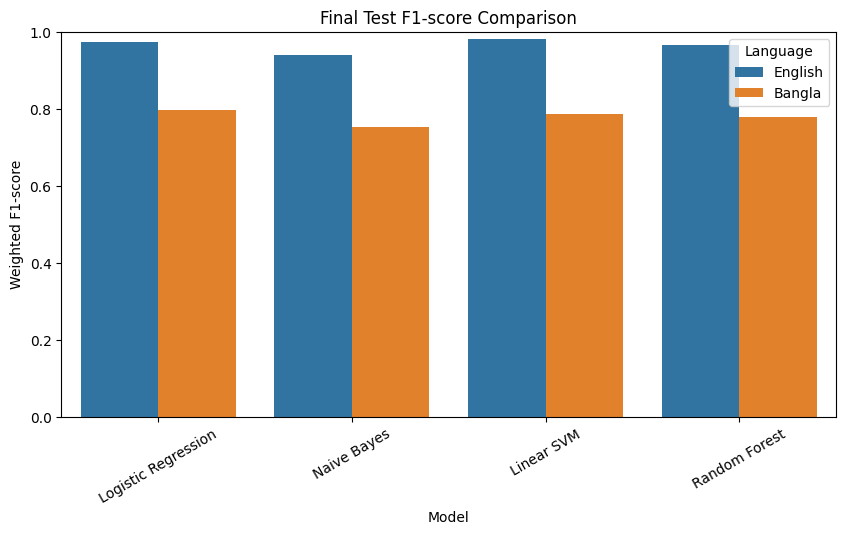

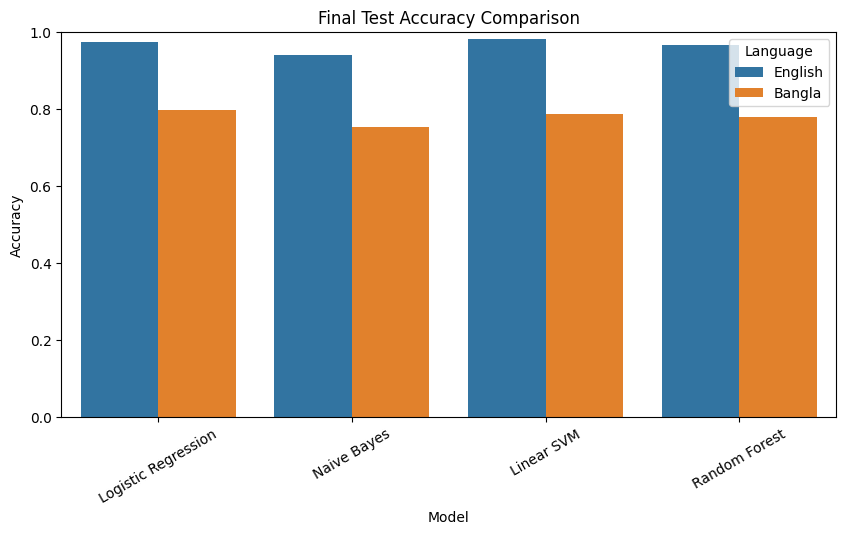

In [46]:
# Step 46: Model Performance Visualization

plt.figure(figsize=(10, 5))
sns.barplot(data=final_results_df, x="Model", y="F1-score", hue="Language")
plt.title("Final Test F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("Weighted F1-score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=final_results_df, x="Model", y="Accuracy", hue="Language")
plt.title("Final Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()


## Confusion Matrix Analysis

Confusion matrices show how many fake and real news samples were correctly or incorrectly classified. This is important because accuracy alone does not explain the type of classification error.


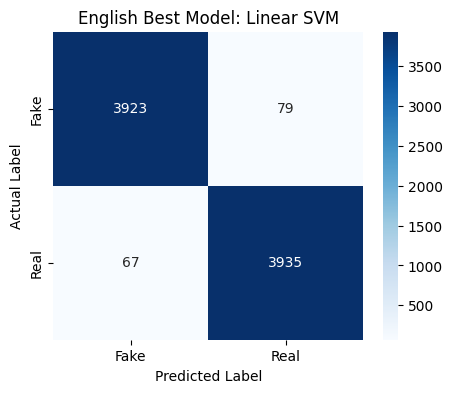

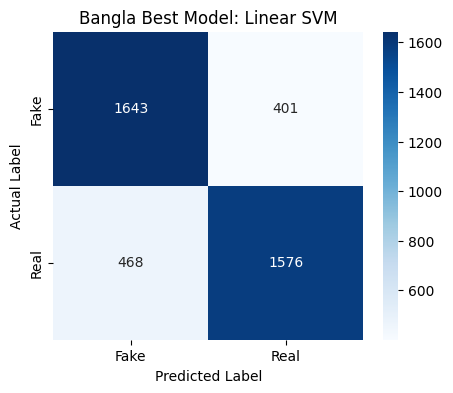

In [47]:
# Step 47: Confusion Matrix Function

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fake", "Real"],
        yticklabels=["Fake", "Real"]
    )
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()
    return cm

best_english_model_name = best_english_test["Model"]
best_bangla_model_name = best_bangla_test["Model"]

english_best_predictions = english_test_predictions[best_english_model_name]
bangla_best_predictions = bangla_test_predictions[best_bangla_model_name]

english_cm = plot_confusion_matrix(y_eng_test, english_best_predictions, f"English Best Model: {best_english_model_name}")
bangla_cm = plot_confusion_matrix(y_ban_test, bangla_best_predictions, f"Bangla Best Model: {best_bangla_model_name}")


In [48]:
# Step 48: Confusion Matrix Values Table

confusion_summary = pd.DataFrame({
    "Language": ["English", "Bangla"],
    "Best Model": [best_english_model_name, best_bangla_model_name],
    "True Fake Predicted Fake": [english_cm[0, 0], bangla_cm[0, 0]],
    "True Fake Predicted Real": [english_cm[0, 1], bangla_cm[0, 1]],
    "True Real Predicted Fake": [english_cm[1, 0], bangla_cm[1, 0]],
    "True Real Predicted Real": [english_cm[1, 1], bangla_cm[1, 1]]
})

display(confusion_summary)


,Language,Best Model,True Fake Predicted Fake,True Fake Predicted Real,True Real Predicted Fake,True Real Predicted Real
0,English,Linear SVM,3923,79,67,3935
1,Bangla,Linear SVM,1643,401,468,1576


## Confusion Matrices for All Models

In addition to the best-model confusion matrices, confusion matrices for all evaluated models are shown to provide a more complete comparison of classification behavior across algorithms.

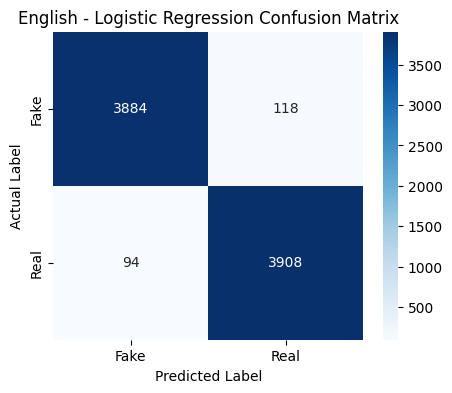

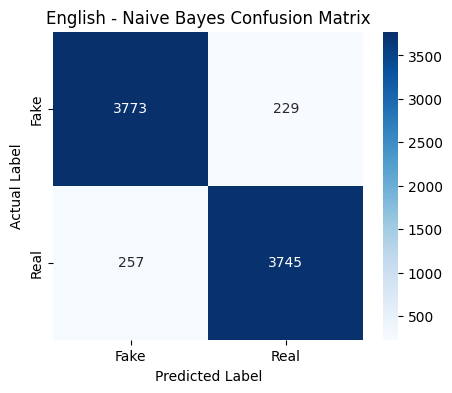

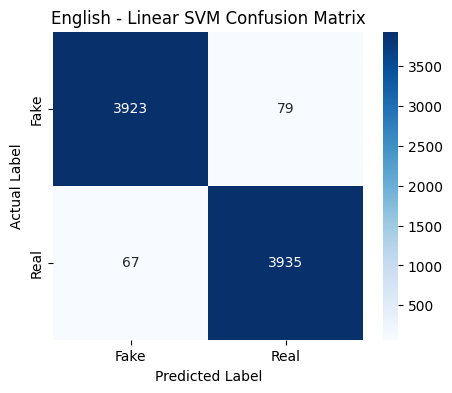

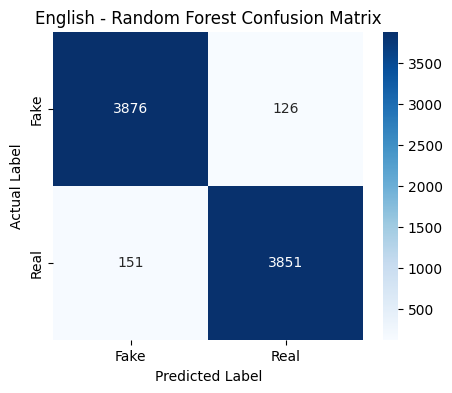

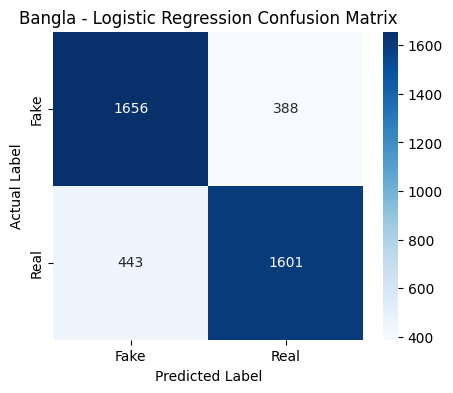

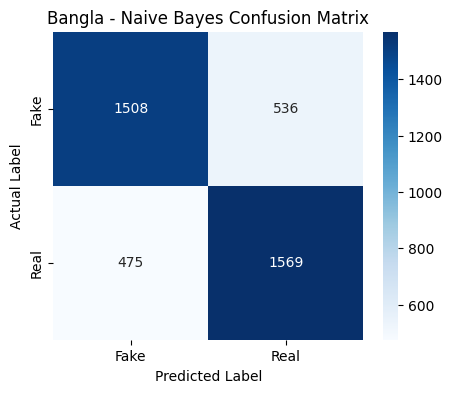

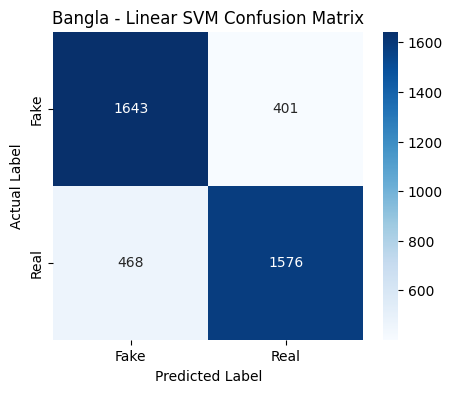

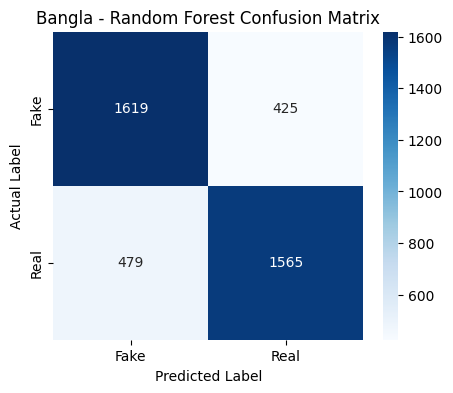

In [49]:
# Step 49: Confusion Matrices for All Models

def plot_all_confusion_matrices(y_true, predictions_dict, language):
    for model_name, y_pred in predictions_dict.items():
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(5, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"]
        )
        plt.title(f"{language} - {model_name} Confusion Matrix")
        plt.xlabel("Predicted Label")
        plt.ylabel("Actual Label")
        plt.show()


plot_all_confusion_matrices(
    y_true=y_eng_test,
    predictions_dict=english_test_predictions,
    language="English"
)

plot_all_confusion_matrices(
    y_true=y_ban_test,
    predictions_dict=bangla_test_predictions,
    language="Bangla"
)

## ROC Curve

ROC-AUC is calculated when model probability scores or decision scores are available. Linear SVM uses a decision function, while Logistic Regression, Naive Bayes, and Random Forest provide probability scores.


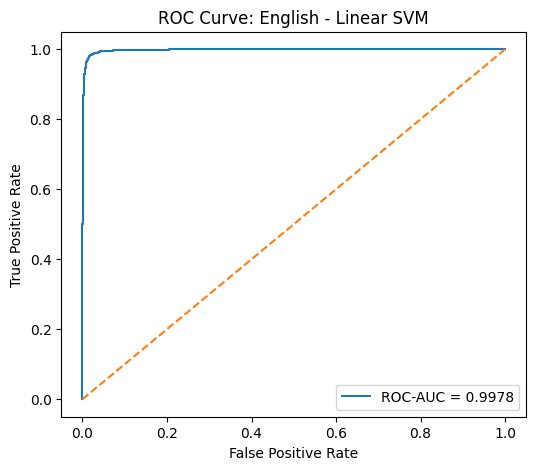

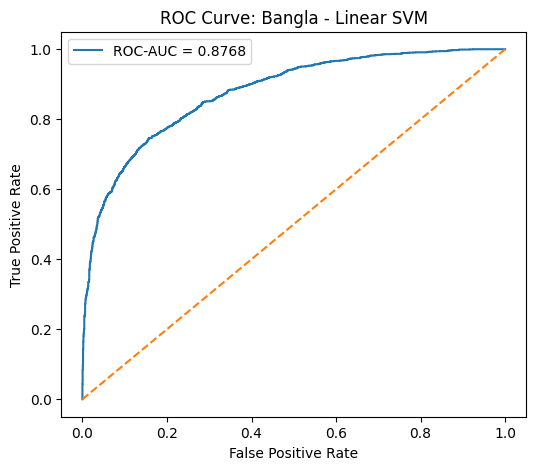

In [50]:
# Step 50: ROC Curve Function for Best Models

def get_model_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    else:
        return None


def plot_roc_for_model(model, X_test, y_test, language, model_name):
    scores = get_model_scores(model, X_test)
    if scores is None:
        print(f"ROC curve not available for {language} - {model_name}")
        return

    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_value = roc_auc_score(y_test, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve: {language} - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

plot_roc_for_model(english_trained_models[best_english_model_name], X_eng_test_tfidf, y_eng_test, "English", best_english_model_name)
plot_roc_for_model(bangla_trained_models[best_bangla_model_name], X_ban_test_tfidf, y_ban_test, "Bangla", best_bangla_model_name)


## Correct Prediction Examples

This section displays correctly predicted examples for each algorithm. Both numeric labels and readable class meanings are shown.


In [51]:
# Step 51: Correct Prediction Examples for Each Algorithm

def show_balanced_correct_predictions(X_test_text, y_test, predictions_dict, language, label_map, n_per_model=5):
    print("=" * 100)
    print(f"Balanced Correct Prediction Examples for {language}")
    print("=" * 100)

    for model_name, y_pred in predictions_dict.items():
        prediction_df = pd.DataFrame({
            "Text": X_test_text.values,
            "Actual Label": y_test.values,
            "Predicted Label": y_pred
        })

        prediction_df = prediction_df[prediction_df["Actual Label"] == prediction_df["Predicted Label"]].copy()
        prediction_df["Actual Output"] = prediction_df["Actual Label"].map(label_map)
        prediction_df["Predicted Output"] = prediction_df["Predicted Label"].map(label_map)

        selected_examples = []
        for label_value in sorted(prediction_df["Actual Label"].unique()):
            class_examples = prediction_df[prediction_df["Actual Label"] == label_value].head(max(1, n_per_model // 2))
            selected_examples.append(class_examples)

        if selected_examples:
            selected_df = pd.concat(selected_examples).head(n_per_model)
        else:
            selected_df = prediction_df.head(n_per_model)

        print(f"\nModel: {model_name}")
        display(selected_df[["Text", "Actual Label", "Actual Output", "Predicted Label", "Predicted Output"]])

show_balanced_correct_predictions(X_eng_test, y_eng_test, english_test_predictions, "English", LABEL_MAP, n_per_model=5)
show_balanced_correct_predictions(X_ban_test, y_ban_test, bangla_test_predictions, "Bangla", LABEL_MAP, n_per_model=5)


Balanced Correct Prediction Examples for English

Model: Logistic Regression


,Text,Actual Label,Actual Output,Predicted Label,Predicted Output
3,smartest woman polit trump knock hillari first debat monica crowley offer brilliant polit analysi conserv media bril...,0,Fake News,0,Fake News
6,these products make men grow breasts get cancers of the prostate and liver posted by eddie owned by unilever the axe...,0,Fake News,0,Fake News
0,cambodia hun sen urg arrest opposit rebel citi phnom penh cambodia could make arrest peopl link plot overthrow gover...,1,Real News,1,Real News
1,irma mix journey home florida evacue orlando fla flee home hurrican irma path sever day ago florida resid lee tinkle...,1,Real News,1,Real News



Model: Naive Bayes


,Text,Actual Label,Actual Output,Predicted Label,Predicted Output
3,smartest woman polit trump knock hillari first debat monica crowley offer brilliant polit analysi conserv media bril...,0,Fake News,0,Fake News
6,these products make men grow breasts get cancers of the prostate and liver posted by eddie owned by unilever the axe...,0,Fake News,0,Fake News
0,cambodia hun sen urg arrest opposit rebel citi phnom penh cambodia could make arrest peopl link plot overthrow gover...,1,Real News,1,Real News
2,rohingya griev babi die border cross shah porir dwip bangladesh cri rohingya mother yellow headscarf cradl fiveweeko...,1,Real News,1,Real News



Model: Linear SVM


...

,Text,Actual Label,Actual Output,Predicted Label,Predicted Output
7,জামাত শিবির সংখ্যালঘু যাতায়াত ভাতা ক্ষতিপুরন হবে: খালেদা নিজস্ব মতিবেদক বৃহত্তর জামায়া ইসলামীর খানকির পোলায় নায়ে...,0,Fake News,0,Fake News
13,বিএনপি ছাড়ার হুমকি দিলেন ফখরুল নিজস্ব মতিবেদকবৃহত্তর জামায়াতে ইসলামীর বিএনপি শাখার ভাঁড়প্রাপ্ত নায়েবে আমীর মির্জ...,0,Fake News,0,Fake News
0,'বিএনপি ১০ বছরে ১০ মিনিটও রাস্তায় দাঁড়াতে পারেনি' আওয়ামী লীগের সাধারণ সম্পাদক এবং সড়ক পরিবহন ও সেতুমন্ত্রী ওবায়...,1,Real News,1,Real News
1,"খেলা দেখার সময় চিকেন কাঠি কাবাব প্রতিটি খেলার দিনই বাড়িতে থাকে খাবারের বিশেষ আয়োজন। আজ আবার ছুটির দিন, সেই সাথে আ...",1,Real News,1,Real News



Model: Linear SVM


,Text,Actual Label,Actual Output,Predicted Label,Predicted Output
3,শাহজাদা বিমান দ্রব্য জব্দ নিজস্ব প্রতিবেদক ঢাকা রত শাহজাদা আন্তর্জাতিক বিমান দ্রব্য জব্দ শুল্ক গোয়েন্দা তদন্ত দপ্তর...,0,Fake News,0,Fake News
7,জামাত শিবির সংখ্যালঘু যাতায়াত ভাতা ক্ষতিপুরন হবে: খালেদা নিজস্ব মতিবেদক বৃহত্তর জামায়া ইসলামীর খানকির পোলায় নায়ে...,0,Fake News,0,Fake News
0,'বিএনপি ১০ বছরে ১০ মিনিটও রাস্তায় দাঁড়াতে পারেনি' আওয়ামী লীগের সাধারণ সম্পাদক এবং সড়ক পরিবহন ও সেতুমন্ত্রী ওবায়...,1,Real News,1,Real News
1,"খেলা দেখার সময় চিকেন কাঠি কাবাব প্রতিটি খেলার দিনই বাড়িতে থাকে খাবারের বিশেষ আয়োজন। আজ আবার ছুটির দিন, সেই সাথে আ...",1,Real News,1,Real News



Model: Random Forest


,Text,Actual Label,Actual Output,Predicted Label,Predicted Output
3,শাহজাদা বিমান দ্রব্য জব্দ নিজস্ব প্রতিবেদক ঢাকা রত শাহজাদা আন্তর্জাতিক বিমান দ্রব্য জব্দ শুল্ক গোয়েন্দা তদন্ত দপ্তর...,0,Fake News,0,Fake News
7,জামাত শিবির সংখ্যালঘু যাতায়াত ভাতা ক্ষতিপুরন হবে: খালেদা নিজস্ব মতিবেদক বৃহত্তর জামায়া ইসলামীর খানকির পোলায় নায়ে...,0,Fake News,0,Fake News
0,'বিএনপি ১০ বছরে ১০ মিনিটও রাস্তায় দাঁড়াতে পারেনি' আওয়ামী লীগের সাধারণ সম্পাদক এবং সড়ক পরিবহন ও সেতুমন্ত্রী ওবায়...,1,Real News,1,Real News
1,"খেলা দেখার সময় চিকেন কাঠি কাবাব প্রতিটি খেলার দিনই বাড়িতে থাকে খাবারের বিশেষ আয়োজন। আজ আবার ছুটির দিন, সেই সাথে আ...",1,Real News,1,Real News


## Statistical Significance Testing

McNemar's test is used to compare whether the difference between two classifiers is statistically meaningful on the same test set. It compares where two models agree and disagree on identical test samples.


In [52]:
# Step 52: Statistical Significance Test Using McNemar's Test

from statsmodels.stats.contingency_tables import mcnemar

def run_mcnemar_test(y_true, pred_a, pred_b, model_a_name, model_b_name, language):
    y_true_values = np.array(y_true)
    pred_a = np.array(pred_a)
    pred_b = np.array(pred_b)

    correct_a = pred_a == y_true_values
    correct_b = pred_b == y_true_values

    both_correct = ((correct_a == True) & (correct_b == True)).sum()
    a_correct_b_wrong = ((correct_a == True) & (correct_b == False)).sum()
    a_wrong_b_correct = ((correct_a == False) & (correct_b == True)).sum()
    both_wrong = ((correct_a == False) & (correct_b == False)).sum()

    table = [
        [int(both_correct), int(a_correct_b_wrong)],
        [int(a_wrong_b_correct), int(both_wrong)]
    ]

    result = mcnemar(table, exact=False, correction=True)

    print(f"{language}: {model_a_name} vs {model_b_name}")
    print("Contingency Table:", table)
    print("McNemar Statistic:", round(result.statistic, 4))
    print("p-value:", f"{result.pvalue:.4e}")

    if result.pvalue < 0.05:
        print("Interpretation: The difference is statistically significant.\n")
    else:
        print("Interpretation: The difference is not statistically significant.\n")


def get_best_and_second_best_model(final_results_df, language):
    language_results = final_results_df[
        final_results_df["Language"] == language
    ].sort_values(by="F1-score", ascending=False)

    best_model = language_results.iloc[0]["Model"]
    second_best_model = language_results.iloc[1]["Model"]

    return best_model, second_best_model


# English: compare best model with second-best model
english_best_model, english_second_best_model = get_best_and_second_best_model(
    final_results_df,
    "English"
)

run_mcnemar_test(
    y_true=y_eng_test,
    pred_a=english_test_predictions[english_best_model],
    pred_b=english_test_predictions[english_second_best_model],
    model_a_name=english_best_model,
    model_b_name=english_second_best_model,
    language="English"
)


# Bangla: compare best model with second-best model
bangla_best_model, bangla_second_best_model = get_best_and_second_best_model(
    final_results_df,
    "Bangla"
)

run_mcnemar_test(
    y_true=y_ban_test,
    pred_a=bangla_test_predictions[bangla_best_model],
    pred_b=bangla_test_predictions[bangla_second_best_model],
    model_a_name=bangla_best_model,
    model_b_name=bangla_second_best_model,
    language="Bangla"
)

English: Linear SVM vs Logistic Regression
Contingency Table: [[7765, 93], [27, 119]]
McNemar Statistic: 35.2083
p-value: 2.9625e-09
Interpretation: The difference is statistically significant.

Bangla: Logistic Regression vs Linear SVM
Contingency Table: [[3016, 241], [203, 628]]
McNemar Statistic: 3.0833
p-value: 7.9098e-02
Interpretation: The difference is not statistically significant.



## Confidence Interval Analysis

To estimate the uncertainty of the final test results, bootstrap 95% confidence intervals are calculated for the best validation-selected model in each language. This provides a range of plausible values for accuracy and F1-score instead of reporting only a single point estimate.

In [53]:
# Step 53: Bootstrap 95% Confidence Intervals for Best Models

from sklearn.metrics import accuracy_score, f1_score

def bootstrap_metric_ci(y_true, y_pred, metric_function, n_bootstrap=1000, confidence=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    scores = []
    n = len(y_true)

    for _ in range(n_bootstrap):
        sample_idx = rng.integers(0, n, n)
        score = metric_function(y_true[sample_idx], y_pred[sample_idx])
        scores.append(score)

    lower = np.percentile(scores, (1 - confidence) / 2 * 100)
    upper = np.percentile(scores, (1 + confidence) / 2 * 100)

    return np.mean(scores), lower, upper

ci_rows = []

for language, y_true, y_pred, model_name in [
    ("English", y_eng_test, english_test_predictions[best_english_validation_model], best_english_validation_model),
    ("Bangla", y_ban_test, bangla_test_predictions[best_bangla_validation_model], best_bangla_validation_model)
]:
    acc_mean, acc_low, acc_high = bootstrap_metric_ci(
        y_true, y_pred, accuracy_score, random_state=RANDOM_STATE
    )

    f1_mean, f1_low, f1_high = bootstrap_metric_ci(
        y_true,
        y_pred,
        lambda yt, yp: f1_score(yt, yp, average="weighted"),
        random_state=RANDOM_STATE
    )

    ci_rows.append({
        "Language": language,
        "Model": model_name,
        "Metric": "Accuracy",
        "Mean": acc_mean,
        "95% CI Lower": acc_low,
        "95% CI Upper": acc_high
    })

    ci_rows.append({
        "Language": language,
        "Model": model_name,
        "Metric": "Weighted F1-score",
        "Mean": f1_mean,
        "95% CI Lower": f1_low,
        "95% CI Upper": f1_high
    })

confidence_interval_table = pd.DataFrame(ci_rows).round(4)
display(confidence_interval_table)

,Language,Model,Metric,Mean,95% CI Lower,95% CI Upper
0,English,Linear SVM,Accuracy,0.9817,0.9789,0.9845
1,English,Linear SVM,Weighted F1-score,0.9817,0.9789,0.9845
2,Bangla,Linear SVM,Accuracy,0.7874,0.7740,0.8004
3,Bangla,Linear SVM,Weighted F1-score,0.7874,0.7739,0.8003


## Pairwise Statistical Comparison

To further examine whether the best-performing classifier differs significantly from other classical machine learning models, pairwise McNemar tests were conducted. Linear SVM was compared against Logistic Regression, Naive Bayes, and Random Forest using the same test samples. This analysis helps determine whether observed performance differences are statistically meaningful beyond numerical metric differences.

Because multiple pairwise comparisons are performed, both raw p-values and Bonferroni-adjusted p-values are reported.

In [54]:
# Step 54: Pairwise McNemar Test for Linear SVM Against Other Models

from statsmodels.stats.contingency_tables import mcnemar

def pairwise_mcnemar_table(y_true, predictions_dict, reference_model, language):
    """
    Compare one reference model against all other models using McNemar's test.
    Reports raw p-value and Bonferroni-adjusted p-value.
    """
    results = []

    y_true_values = np.array(y_true)
    reference_pred = np.array(predictions_dict[reference_model])

    comparison_models = [
        model_name for model_name in predictions_dict.keys()
        if model_name != reference_model
    ]

    number_of_comparisons = len(comparison_models)

    for comparison_model in comparison_models:
        comparison_pred = np.array(predictions_dict[comparison_model])

        reference_correct = reference_pred == y_true_values
        comparison_correct = comparison_pred == y_true_values

        both_correct = ((reference_correct == True) & (comparison_correct == True)).sum()
        reference_correct_comparison_wrong = ((reference_correct == True) & (comparison_correct == False)).sum()
        reference_wrong_comparison_correct = ((reference_correct == False) & (comparison_correct == True)).sum()
        both_wrong = ((reference_correct == False) & (comparison_correct == False)).sum()

        contingency_table = [
            [int(both_correct), int(reference_correct_comparison_wrong)],
            [int(reference_wrong_comparison_correct), int(both_wrong)]
        ]

        test_result = mcnemar(
            contingency_table,
            exact=False,
            correction=True
        )

        raw_p_value = test_result.pvalue
        bonferroni_adjusted_p_value = min(raw_p_value * number_of_comparisons, 1.0)

        if bonferroni_adjusted_p_value < 0.05:
            interpretation = "Significant after Bonferroni correction"
        elif raw_p_value < 0.05:
            interpretation = "Significant before correction only"
        else:
            interpretation = "Not statistically significant"

        results.append({
            "Language": language,
            "Reference Model": reference_model,
            "Comparison Model": comparison_model,
            "Both Correct": int(both_correct),
            "Reference Correct / Comparison Wrong": int(reference_correct_comparison_wrong),
            "Reference Wrong / Comparison Correct": int(reference_wrong_comparison_correct),
            "Both Wrong": int(both_wrong),
            "McNemar Statistic": round(test_result.statistic, 4),
            "Raw p-value": round(raw_p_value, 6),
            "Bonferroni-adjusted p-value": round(bonferroni_adjusted_p_value, 6),
            "Interpretation": interpretation
        })

    return pd.DataFrame(results)


# English pairwise comparison: Linear SVM vs other models
english_pairwise_mcnemar = pairwise_mcnemar_table(
    y_true=y_eng_test,
    predictions_dict=english_test_predictions,
    reference_model="Linear SVM",
    language="English"
)

# Bangla pairwise comparison: Linear SVM vs other models
bangla_pairwise_mcnemar = pairwise_mcnemar_table(
    y_true=y_ban_test,
    predictions_dict=bangla_test_predictions,
    reference_model="Linear SVM",
    language="Bangla"
)

# Combine English and Bangla results
pairwise_mcnemar_results = pd.concat(
    [english_pairwise_mcnemar, bangla_pairwise_mcnemar],
    ignore_index=True
)

display(pairwise_mcnemar_results)

,Language,Reference Model,Comparison Model,Both Correct,Reference Correct / Comparison Wrong,Reference Wrong / Comparison Correct,Both Wrong,McNemar Statistic,Raw p-value,Bonferroni-adjusted p-value,Interpretation
0,English,Linear SVM,Logistic Regression,7765,93,27,119,35.2083,0.000000,0.000000,Significant after Bonferroni correction
1,English,Linear SVM,Naive Bayes,7471,387,47,99,264.7949,0.000000,0.000000,Significant after Bonferroni correction
2,English,Linear SVM,Random Forest,7676,182,51,95,72.5322,0.000000,0.000000,Significant after Bonferroni correction
3,Bangla,Linear SVM,Logistic Regression,3016,203,241,628,3.0833,0.079098,0.237295,Not statistically significant
4,Bangla,Linear SVM,Naive Bayes,2720,499,357,512,23.2255,0.000001,0.000004,Significant after Bonferroni correction
5,Bangla,Linear SVM,Random Forest,2845,374,339,530,1.6213,0.202908,0.608724,Not statistically significant


## Error Analysis

Error analysis helps explain model limitations beyond numerical scores. Misclassified fake and real news examples are reviewed to identify possible causes such as ambiguous vocabulary, short text, overlapping political terms, and cases requiring external factual knowledge.


In [55]:
# Step 55: Error Analysis Function

def show_misclassified_examples(X_test_text, y_test, y_pred, language, model_name, n=10):
    error_df = pd.DataFrame({
        "Text": X_test_text.values,
        "Actual Label": y_test.values,
        "Predicted Label": y_pred
    })

    error_df = error_df[error_df["Actual Label"] != error_df["Predicted Label"]].copy()
    error_df["Actual Meaning"] = error_df["Actual Label"].map(LABEL_MAP)
    error_df["Predicted Meaning"] = error_df["Predicted Label"].map(LABEL_MAP)

    print(f"Misclassified Examples for {language} - {model_name}")
    print("Number of Misclassified Examples:", error_df.shape[0])
    print(f"\nShowing first {n} misclassified examples:")

    display(error_df.head(n))
    return error_df

english_error_df = show_misclassified_examples(
    X_test_text=X_eng_test,
    y_test=y_eng_test,
    y_pred=english_best_predictions,
    language="English",
    model_name=best_english_model_name,
    n=10
)

bangla_error_df = show_misclassified_examples(
    X_test_text=X_ban_test,
    y_test=y_ban_test,
    y_pred=bangla_best_predictions,
    language="Bangla",
    model_name=best_bangla_model_name,
    n=10
)


Misclassified Examples for English - Linear SVM
Number of Misclassified Examples: 146

Showing first 10 misclassified examples:


,Text,Actual Label,Predicted Label,Actual Meaning,Predicted Meaning
15,sex and the presidential city email why does everyone think that presidential campaigns are about issues when anyone...,0,1,Fake News,Real News
45,what wikileaks hack says about clinton our view now we know why she didn t want those wall street speeches made publ...,1,0,Real News,Fake News
60,black americans going for donald trump in record numbers as election day approaches nteb ads privacy policy black am...,0,1,Fake News,Real News
150,sander say would prefer elizabeth warren kain vice presidenti pick former democrat presidenti candid senat berni san...,1,0,Real News,Fake News
200,the media needs to stop telling this lie about donald trump i m a sanders supporter and value honesty back in june i...,1,0,Real News,Fake News
207,oil prices could fall further if iran nuclear deal is reached two of the biggest news stories of 2015 have been the ...,1,0,Real News,Fake News
219,huma may have violated legal obligation regarding classified info foia request shows print republican national commi...,0,1,Fake News,Real News
282,shame last hope kill iran nuke deal block senat like obamacar push iran nuke deal push spite unpopular american peop...,0,1,Fake News,Real News
308,hey bernie supporters here are 45 times hillary promoted the tpp truthfeed 11 july 10 2012 remarks with foreign mini...,0,1,Fake News,Real News
319,when white nationalists show up to monitor the polls many americans of different political stripes share concerns ab...,1,0,Real News,Fake News


Misclassified Examples for Bangla - Linear SVM
Number of Misclassified Examples: 869

Showing first 10 misclassified examples:


,Text,Actual Label,Predicted Label,Actual Meaning,Predicted Meaning
2,বাংলাদেশ কারিগরি শিক্ষাবোর্ডে নিয়োগ বাংলাদেশ কারিগরি শিক্ষাবোর্ড নিম্নলিখিত পদসমূহে অস্থায়ী ভিত্তিতে নিয়োগের জন্য...,0,1,Fake News,Real News
10,চাকরিতে প্রবেশের বয়সসীমা ৩৫ বছর দ্রুত বাস্তবায়নের দাবি চাকরিতে প্রবেশের বয়সসীমা ৩৫ বছরে উন্নীত করার সুপারিশ দ্রুত...,1,0,Real News,Fake News
16,মোবাইলফোন আসক্তিকে লাল কার্ড দেখালো শিক্ষার্থীরা কুমিল্লার বুড়িচং উপজেলার শিক্ষার্থীরা মোবাইলফোন আসক্তিকে লাল কার্ড...,0,1,Fake News,Real News
25,মিস ইউ তানজিন তিশা চলতি সময়ের জনপ্রিয় মডেল-অভিনেত্রী তানজিন তিশাকে মিস করছেন কেউ একজন। কে সে এবং কেন তাকে মিস করছে...,1,0,Real News,Fake News
28,রাজধানীতে চাকরি ছেড়ে বাদাম বিক্রি করছেন কলেজছা’ত্রী তাহমিনা! রাজধানীর লালমাটিয়া মহিলা কলেজের ছা’ত্রী তাহমিনা কথা। ...,0,1,Fake News,Real News
29,স্ত্রী নির্যাতন মামলা মানবাধিকার কর্মকর্তা কারাগার রাজশাহী: যৌতুক দাবি স্ত্রী নির্যাতন মামলা জাতিসংঘ মানবাধিকার কর্ম...,0,1,Fake News,Real News
32,পায় বন্দর অভিজ্ঞ চাকরি সুযোগ পায় বন্দর কর্তৃপক্ষে পদ জনক নিয়োগ হবু আগ্রহ অক্টোব আবেদন পারবেন। প্রতিষ্ঠান নাম পায়...,0,1,Fake News,Real News
39,আর্জেন্টিনা দলে আর ফেরার দরকার নেই: মেসিকে ম্যারাডোনা ডিয়েগো ম্যারাডোনার ঠোঁটকাটা স্বভাবের কথা সবারই জানা। তিনি যখন...,1,0,Real News,Fake News
47,বাগেরহাটে সাইকেল চালাক গুল হত্যা বাগেরহাটে হাসান () নাম ভাড়া সাইকেল চালাক গুল হত্যা দুর্বৃত্তরা। সময় দুজন দের খুলন...,0,1,Fake News,Real News
52,সাজ যে চোখের কথা বলে নাটকীয়তা। পাশ্চাত্যের রূপসজ্জায় এই ধারা চলছে এখন। সামনে আসছে শীত ও বসন্ত। এই দুই ঋতু ধরেই সাজ...,1,0,Real News,Fake News


## Error Category Analysis

The misclassified samples were further grouped into broad error categories. This helps explain why the models may confuse fake and real news beyond the numerical scores. The categories are manually interpretable and are used only for qualitative analysis.

In [56]:
# Step 56: Rule-Based Error Category Analysis

def assign_error_category(text):
    text = str(text).lower()
    word_count = len(text.split())

    political_terms = [
        "trump", "biden", "election", "government", "minister", "president",
        "নির্বাচন", "সরকার", "মন্ত্রী", "প্রধানমন্ত্রী", "আওয়ামী", "বিএনপি"
    ]

    sensational_terms = [
        "shocking", "breaking", "viral", "exposed", "secret", "watch",
        "ভাইরাল", "অবিশ্বাস্য", "চাঞ্চল্যকর", "গোপন", "দেখুন"
    ]

    if word_count < 50:
        return "Short text / limited context"
    elif any(term in text for term in sensational_terms):
        return "Sensational or viral-style wording"
    elif any(term in text for term in political_terms):
        return "Political or named-entity-heavy content"
    elif word_count > 500:
        return "Very long article"
    else:
        return "General lexical/semantic ambiguity"

def summarize_error_categories(error_df, language):
    temp = error_df.copy()
    temp["Error Category"] = temp["Text"].apply(assign_error_category)

    summary = (
        temp.groupby("Error Category")
        .size()
        .reset_index(name="Number of Errors")
        .sort_values("Number of Errors", ascending=False)
    )

    summary["Language"] = language
    return summary[["Language", "Error Category", "Number of Errors"]]

english_error_category_summary = summarize_error_categories(english_error_df, "English")
bangla_error_category_summary = summarize_error_categories(bangla_error_df, "Bangla")

error_category_summary = pd.concat(
    [english_error_category_summary, bangla_error_category_summary],
    ignore_index=True
)

display(error_category_summary)

,Language,Error Category,Number of Errors
0,English,Sensational or viral-style wording,54
1,English,Political or named-entity-heavy content,50
2,English,General lexical/semantic ambiguity,31
3,English,Short text / limited context,6
4,English,Very long article,5
5,Bangla,General lexical/semantic ambiguity,449
6,Bangla,Political or named-entity-heavy content,293
7,Bangla,Sensational or viral-style wording,82
8,Bangla,Very long article,39
9,Bangla,Short text / limited context,6


In [57]:
# Step 57: Error Type Summary

def error_type_summary(error_df, language):
    if error_df.empty:
        return pd.DataFrame({"Language": [language], "Error Type": ["No errors"], "Count": [0]})

    error_df = error_df.copy()
    error_df["Error Type"] = error_df.apply(
        lambda row: "Fake predicted as Real" if row["Actual Label"] == 0 and row["Predicted Label"] == 1 else "Real predicted as Fake",
        axis=1
    )

    summary = error_df["Error Type"].value_counts().reset_index()
    summary.columns = ["Error Type", "Count"]
    summary.insert(0, "Language", language)
    return summary

error_summary_table = pd.concat([
    error_type_summary(english_error_df, "English"),
    error_type_summary(bangla_error_df, "Bangla")
], ignore_index=True)

display(error_summary_table)


,Language,Error Type,Count
0,English,Fake predicted as Real,79
1,English,Real predicted as Fake,67
2,Bangla,Real predicted as Fake,468
3,Bangla,Fake predicted as Real,401


## Error Analysis Discussion

The misclassified examples provide insight into the limitations of the trained models beyond numerical performance scores. Some fake news samples may be predicted as real when they follow a formal or professional news-writing style, while some real news samples may be misclassified when they contain emotional, political, or sensational vocabulary.

For English text, classification errors may occur when fake and real articles share similar topics, vocabulary, or writing structure. For Bangla text, errors may also be influenced by spelling variation, morphology, informal wording, named-entity variation, and overlapping political or social terms. These findings suggest that TF-IDF-based classical machine learning models are useful baseline systems, but they may not fully capture deeper contextual and semantic meaning.

## Bangla Language Challenges

Bangla fake news detection presents several language-specific challenges. Bangla is a comparatively low-resource language, and fake news texts may contain spelling variation, informal writing, named-entity variation, code-mixed expressions, and morphology-rich word forms. These characteristics can make TF-IDF-based feature representation more challenging than English.

In addition, some Bangla fake news may use political, social, or emotional vocabulary that overlaps with real news articles. Therefore, classification errors may occur when fake and real news share similar topics or writing styles. This highlights the importance of error analysis and careful interpretation of model predictions.

## TF-IDF Feature Interpretation

For linear models such as Logistic Regression and Linear SVM, feature weights can be inspected to identify n-grams associated with each class. These features should be interpreted carefully as model-associated indicators, not absolute evidence of truth or falsehood.


In [58]:
# Step 58: Top TF-IDF Features for Logistic Regression

def show_top_logistic_features(model, vectorizer, language, top_n=20):
    if not hasattr(model, "coef_"):
        print(f"{language}: This model does not provide linear coefficients.")
        return None

    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = model.coef_[0]

    top_real_idx = np.argsort(coefs)[-top_n:][::-1]
    top_fake_idx = np.argsort(coefs)[:top_n]

    feature_df = pd.DataFrame({
        "Language": [language] * (top_n * 2),
        "Class Association": ["Real News (1)"] * top_n + ["Fake News (0)"] * top_n,
        "Feature": list(feature_names[top_real_idx]) + list(feature_names[top_fake_idx]),
        "Coefficient": list(coefs[top_real_idx]) + list(coefs[top_fake_idx])
    })

    display(feature_df)
    return feature_df

english_lr_model = english_trained_models["Logistic Regression"]
bangla_lr_model = bangla_trained_models["Logistic Regression"]

english_top_features = show_top_logistic_features(english_lr_model, english_tfidf, "English", top_n=20)
bangla_top_features = show_top_logistic_features(bangla_lr_model, bangla_tfidf, "Bangla", top_n=20)


,Language,Class Association,Feature,Coefficient
0,English,Real News (1),said,13.133673
1,English,Real News (1),presid donald,5.461418
2,English,Real News (1),tuesday,5.396938
3,English,Real News (1),wednesday,4.970736
4,English,Real News (1),thursday,4.914632
5,English,Real News (1),us,4.849391
6,English,Real News (1),monday,4.675083
7,English,Real News (1),us presid,4.673833
8,English,Real News (1),friday,4.408513
9,English,Real News (1),said statement,3.762560


,Language,Class Association,Feature,Coefficient
0,Bangla,Real News (1),২০১৮,7.009632
1,Bangla,Real News (1),অক বর,6.026892
2,Bangla,Real News (1),বর ২০১৮,4.996191
3,Bangla,Real News (1),অক,4.799084
4,Bangla,Real News (1),এশ,4.097062
5,Bangla,Real News (1),ইমস,3.502194
6,Bangla,Real News (1),আইএম,2.935927
7,Bangla,Real News (1),উন নয,2.762065
8,Bangla,Real News (1),এমএস,2.745950
9,Bangla,Real News (1),ইত,2.699442


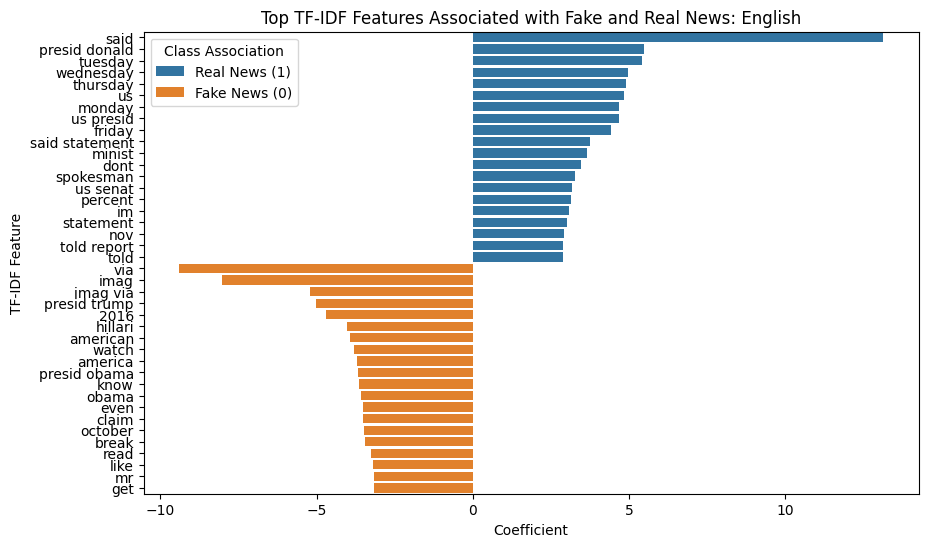

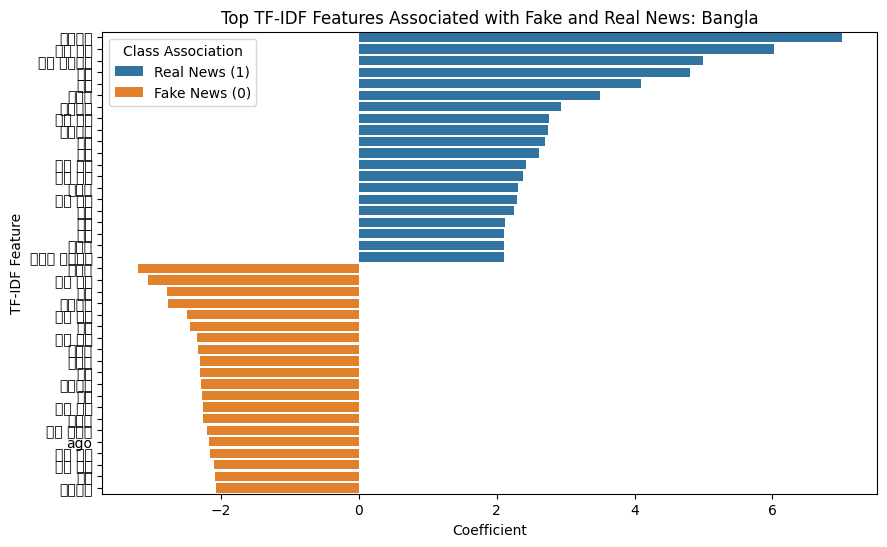

In [59]:
# Step 59: Visualize Top Logistic Regression Features

def plot_top_features(feature_df, language):
    if feature_df is None:
        return

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_df, x="Coefficient", y="Feature", hue="Class Association")
    plt.title(f"Top TF-IDF Features Associated with Fake and Real News: {language}")
    plt.xlabel("Coefficient")
    plt.ylabel("TF-IDF Feature")
    plt.show()

plot_top_features(english_top_features, "English")
plot_top_features(bangla_top_features, "Bangla")


## TF-IDF Ablation Study

An ablation study was conducted to examine how different TF-IDF configurations affect fake news detection performance. The purpose of this experiment is to evaluate whether unigram features alone are sufficient or whether adding bigram features improves model performance.

To keep the ablation focused and computationally efficient, Linear SVM was used as the classifier because it showed strong performance in the main experiments. The ablation was performed on the validation set only, while the test set remained reserved for final model reporting.

In [60]:
# Step 60: TF-IDF Ablation Study Using Linear SVM

def run_tfidf_ablation(
    X_train,
    y_train,
    X_val,
    y_val,
    language,
    best_c,
    lowercase_setting
):
    """
    Runs TF-IDF ablation experiments using Linear SVM.
    The validation set is used for comparison.
    The test set is not used in this ablation to avoid test-set overuse.
    """

    ablation_configs = [{
            "Configuration": "Unigram, 10k features",
            "ngram_range": (1, 1),
            "max_features": 10000
        },
        {
            "Configuration": "Unigram, 20k features",
            "ngram_range": (1, 1),
            "max_features": 20000
        },
        {
            "Configuration": "Unigram + Bigram, 10k features",
            "ngram_range": (1, 2),
            "max_features": 10000
        },
        {
            "Configuration": "Unigram + Bigram, 20k features",
            "ngram_range": (1, 2),
            "max_features": 20000
        }
    ]

    ablation_results = []
    for config in ablation_configs:
        vectorizer = TfidfVectorizer(
            max_features=config["max_features"],
            ngram_range=config["ngram_range"],
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            lowercase=lowercase_setting
        )

        X_train_tfidf_ablation = vectorizer.fit_transform(X_train)
        X_val_tfidf_ablation = vectorizer.transform(X_val)
        model = LinearSVC(
            C=best_c,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=10000
        )

        model.fit(X_train_tfidf_ablation, y_train)
        y_val_pred = model.predict(X_val_tfidf_ablation)
        ablation_results.append({
            "Language": language,
            "Configuration": config["Configuration"],
            "ngram_range": str(config["ngram_range"]),
            "max_features": config["max_features"],
            "Validation Accuracy": accuracy_score(y_val, y_val_pred),
            "Validation Precision": precision_score(y_val, y_val_pred, average="weighted", zero_division=0),
            "Validation Recall": recall_score(y_val, y_val_pred, average="weighted", zero_division=0),
            "Validation F1-score": f1_score(y_val, y_val_pred, average="weighted", zero_division=0),
            "Validation Macro-F1": f1_score(y_val, y_val_pred, average="macro", zero_division=0)
        })
    return pd.DataFrame(ablation_results)

# English TF-IDF ablation
english_ablation_df = run_tfidf_ablation(
    X_train=X_eng_train,
    y_train=y_eng_train,
    X_val=X_eng_val,
    y_val=y_eng_val,
    language="English",
    best_c=best_c_english,
    lowercase_setting=True
)
# Bangla TF-IDF ablation
bangla_ablation_df = run_tfidf_ablation(
    X_train=X_ban_train,
    y_train=y_ban_train,
    X_val=X_ban_val,
    y_val=y_ban_val,
    language="Bangla",
    best_c=best_c_bangla,
    lowercase_setting=False
)
# Combine ablation results
ablation_results_df = pd.concat(
    [english_ablation_df, bangla_ablation_df],
    ignore_index=True
)

ablation_results_df = ablation_results_df.round(4)
display(ablation_results_df)

,Language,Configuration,ngram_range,max_features,Validation Accuracy,Validation Precision,Validation Recall,Validation F1-score,Validation Macro-F1
0,English,"Unigram, 10k features","(1, 1)",10000,0.9725,0.9725,0.9725,0.9725,0.9725
1,English,"Unigram, 20k features","(1, 1)",20000,0.9758,0.9758,0.9758,0.9758,0.9758
2,English,"Unigram + Bigram, 10k features","(1, 2)",10000,0.9775,0.9775,0.9775,0.9775,0.9775
3,English,"Unigram + Bigram, 20k features","(1, 2)",20000,0.9800,0.9800,0.9800,0.9800,0.9800
4,Bangla,"Unigram, 10k features","(1, 1)",10000,0.7622,0.7628,0.7622,0.7621,0.7621
5,Bangla,"Unigram, 20k features","(1, 1)",20000,0.7622,0.7628,0.7622,0.7621,0.7621
6,Bangla,"Unigram + Bigram, 10k features","(1, 2)",10000,0.7872,0.7875,0.7872,0.7871,0.7871
7,Bangla,"Unigram + Bigram, 20k features","(1, 2)",20000,0.7994,0.8000,0.7994,0.7993,0.7993


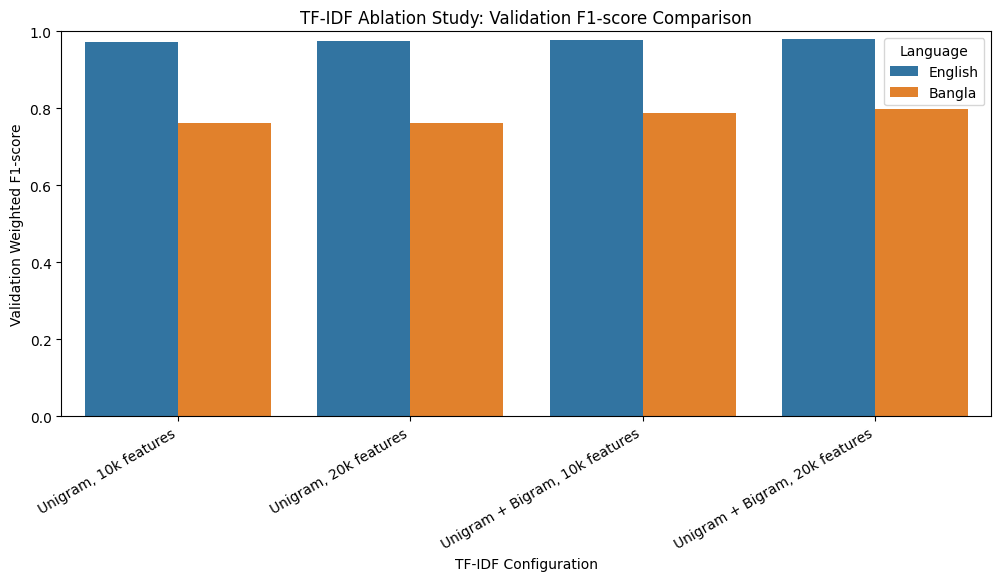

In [61]:
# Step 61: Visualize TF-IDF Ablation Results

plt.figure(figsize=(12, 5))
sns.barplot(
    data=ablation_results_df,
    x="Configuration",
    y="Validation F1-score",
    hue="Language"
)

plt.title("TF-IDF Ablation Study: Validation F1-score Comparison")
plt.xlabel("TF-IDF Configuration")
plt.ylabel("Validation Weighted F1-score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Language")
plt.show()

## Ablation Study Interpretation

The ablation results compare different TF-IDF configurations using Linear SVM on the validation set. If unigram + bigram features perform better than unigram-only features, it suggests that local word-pair patterns provide useful information for fake news detection. If increasing the number of TF-IDF features improves performance, it suggests that a larger vocabulary helps the classifier capture more discriminative terms.

The final test set was not used during the ablation process. This helps preserve the test set for unbiased final performance reporting.

## Bangla vs English Comparative Analysis

The final comparison examines whether model performance differs between Bangla and English. Differences may be related to dataset characteristics, language resource availability, preprocessing, morphology, vocabulary variation, and source distribution.


In [62]:
# Step 62: Best Model Comparison Table

best_model_comparison = pd.DataFrame({
    "Language": ["English", "Bangla"],
    "Best Model": [best_english_test["Model"], best_bangla_test["Model"]],
    "Accuracy": [best_english_test["Accuracy"], best_bangla_test["Accuracy"]],
    "Precision": [best_english_test["Precision"], best_bangla_test["Precision"]],
    "Recall": [best_english_test["Recall"], best_bangla_test["Recall"]],
    "F1-score": [best_english_test["F1-score"], best_bangla_test["F1-score"]],
    "Macro-F1": [best_english_test["Macro-F1"], best_bangla_test["Macro-F1"]],
    "ROC-AUC": [best_english_test["ROC-AUC"], best_bangla_test["ROC-AUC"]]
})

best_model_comparison = best_model_comparison.round(4)
display(best_model_comparison)


,Language,Best Model,Accuracy,Precision,Recall,F1-score,Macro-F1,ROC-AUC
0,English,Linear SVM,0.9818,0.9818,0.9818,0.9818,0.9818,0.9978
1,Bangla,Linear SVM,0.7874,0.7877,0.7874,0.7874,0.7874,0.8768


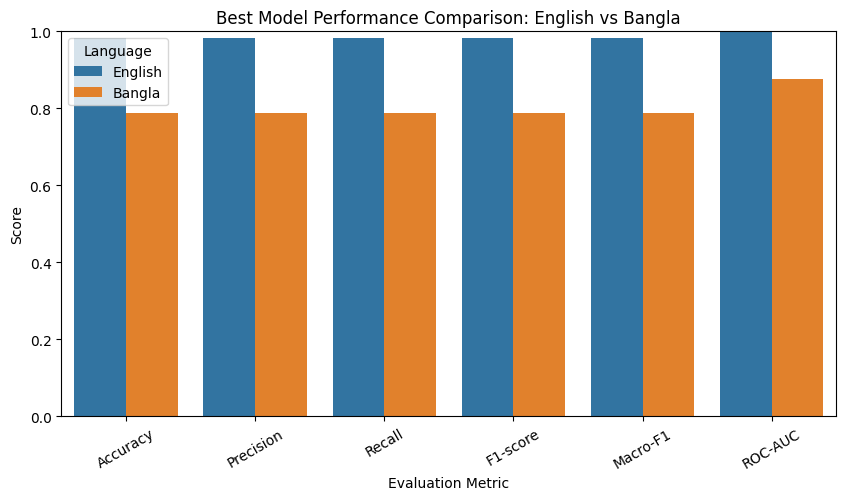

In [63]:
# Step 63: Final Comparative Bar Chart

comparison_melted = best_model_comparison.melt(
    id_vars=["Language", "Best Model"],
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "Macro-F1", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Language")
plt.title("Best Model Performance Comparison: English vs Bangla")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

## Performance Gap Discussion

The final results show a noticeable performance difference between English and Bangla fake news detection. English models achieved higher performance, which may be related to more standardized writing patterns, richer NLP resources, and more consistent vocabulary representation. In contrast, Bangla fake news detection is more challenging because Bangla text may contain spelling variation, informal expressions, morphology-rich word forms, named-entity variation, and topic overlap between fake and real news.

This performance gap suggests that TF-IDF-based classical machine learning models provide useful baseline performance but may not fully capture the deeper contextual and semantic features needed for more robust Bangla fake news detection.

## Transformer Baseline Experiments

To strengthen the study beyond classical machine learning models, transformer-based baselines are added as additional experiments. Classical models using TF-IDF features are useful because they are interpretable, fast, and computationally efficient. However, recent NLP studies commonly compare classical models with transformer models because transformers can capture deeper contextual information from text.

For Bangla fake-news detection, BanglaBERT is used as a Bangla-specific transformer baseline. For cross-lingual comparison, multilingual BERT and XLM-RoBERTa are used as multilingual transformer baselines.

The transformer experiments are reported separately from the main TF-IDF classical machine learning pipeline.

In [64]:
# Step 64: Install and Import Transformer Libraries

!pip -q install transformers datasets accelerate evaluate

import os
import gc
import torch
import numpy as np
import pandas as pd

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 89.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26

## Transformer Dataset Preparation

The same train, validation, and test splits used in the classical machine learning experiments are used for the transformer experiments. This avoids data leakage and ensures that model comparisons are fair.

In [65]:
# Step 65: Prepare Dataset for Transformer Models

def prepare_transformer_dataframe(df):
    df = df.copy()
    df = df[["text", "label"]].dropna()
    df["text"] = df["text"].astype(str).str.strip()
    df = df[df["text"] != ""]
    df["label"] = df["label"].astype(int)
    df = df[df["label"].isin([0, 1])]
    return df.reset_index(drop=True)

bangla_train_tf = prepare_transformer_dataframe(bangla_train)
bangla_validation_tf = prepare_transformer_dataframe(bangla_validation)
bangla_test_tf = prepare_transformer_dataframe(bangla_test)

english_train_tf = prepare_transformer_dataframe(english_train)
english_validation_tf = prepare_transformer_dataframe(english_validation)
english_test_tf = prepare_transformer_dataframe(english_test)

print("Bangla train:", bangla_train_tf.shape)
print("Bangla validation:", bangla_validation_tf.shape)
print("Bangla test:", bangla_test_tf.shape)

print("English train:", english_train_tf.shape)
print("English validation:", english_validation_tf.shape)
print("English test:", english_test_tf.shape)

Bangla train: (14308, 2)
Bangla validation: (2044, 2)
Bangla test: (4088, 2)
English train: (28014, 2)
English validation: (4002, 2)
English test: (8004, 2)


## Transformer Training Function

A reusable training function is used for all transformer models. The function performs tokenization, model fine-tuning, validation, final test evaluation, and metric reporting.

In [66]:
# Step 66: Transformer Training and Evaluation Function

def compute_transformer_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision_weighted": precision_score(labels, predictions, average="weighted", zero_division=0),
        "recall_weighted": recall_score(labels, predictions, average="weighted", zero_division=0),
        "f1_weighted": f1_score(labels, predictions, average="weighted", zero_division=0),
        "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0)
    }


def run_transformer_experiment(
    model_name,
    train_df,
    validation_df,
    test_df,
    language,
    experiment_name,
    max_length=256,
    num_train_epochs=2,
    batch_size=8,
    learning_rate=2e-5
):
    print("=" * 80)
    print(f"Running experiment: {experiment_name}")
    print(f"Language: {language}")
    print(f"Model: {model_name}")
    print("=" * 80)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = Dataset.from_pandas(train_df)
    validation_dataset = Dataset.from_pandas(validation_df)
    test_dataset = Dataset.from_pandas(test_df)

    def tokenize_function(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=max_length
        )

    train_dataset = train_dataset.map(tokenize_function, batched=True)
    validation_dataset = validation_dataset.map(tokenize_function, batched=True)
    test_dataset = test_dataset.map(tokenize_function, batched=True)

    train_dataset = train_dataset.remove_columns(["text"])
    validation_dataset = validation_dataset.remove_columns(["text"])
    test_dataset = test_dataset.remove_columns(["text"])

    train_dataset.set_format("torch")
    validation_dataset.set_format("torch")
    test_dataset.set_format("torch")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        ignore_mismatched_sizes=True
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    output_dir = f"./transformer_output_{experiment_name.replace(' ', '_').replace('/', '_')}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_train_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        logging_steps=100,
        save_total_limit=1,
        report_to="none",
        seed=RANDOM_STATE
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=validation_dataset,
        data_collator=data_collator,
        compute_metrics=compute_transformer_metrics
    )

    trainer.train()

    test_output = trainer.predict(test_dataset)
    test_logits = test_output.predictions
    test_predictions = np.argmax(test_logits, axis=1)
    y_true = test_df["label"].values

    result = {
        "Language": language,
        "Experiment": experiment_name,
        "Model": model_name,
        "Test Accuracy": accuracy_score(y_true, test_predictions),
        "Test Precision": precision_score(y_true, test_predictions, average="weighted", zero_division=0),
        "Test Recall": recall_score(y_true, test_predictions, average="weighted", zero_division=0),
        "Test F1-score": f1_score(y_true, test_predictions, average="weighted", zero_division=0),
        "Test Macro-F1": f1_score(y_true, test_predictions, average="macro", zero_division=0)
    }

    report = classification_report(
        y_true,
        test_predictions,
        target_names=["Fake News (0)", "Real News (1)"],
        zero_division=0
    )

    cm = confusion_matrix(y_true, test_predictions)

    print("\nTest Result:")
    print(result)

    print("\nClassification Report:")
    print(report)

    print("\nConfusion Matrix:")
    print(cm)

    del model
    del trainer
    torch.cuda.empty_cache()
    gc.collect()

    return result, test_predictions

## BanglaBERT Baseline for Bangla

BanglaBERT is used as a Bangla-specific transformer model. This experiment helps determine whether a language-specific transformer improves performance over classical TF-IDF based models.

In [67]:
# Step 67: BanglaBERT Baseline for Bangla

banglabert_result, banglabert_test_predictions = run_transformer_experiment(
    model_name="csebuetnlp/banglabert",
    train_df=bangla_train_tf,
    validation_df=bangla_validation_tf,
    test_df=bangla_test_tf,
    language="Bangla",
    experiment_name="BanglaBERT Bangla",
    max_length=256,
    num_train_epochs=2,
    batch_size=8,
    learning_rate=2e-5
)

Running experiment: BanglaBERT Bangla
Language: Bangla
Model: csebuetnlp/banglabert


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,0.739517,0.746963,0.842466,0.843102,0.842466,0.842393,0.842393
2,0.567145,0.701642,0.862035,0.862057,0.862035,0.862033,0.862033


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye


Test Result:
{'Language': 'Bangla', 'Experiment': 'BanglaBERT Bangla', 'Model': 'csebuetnlp/banglabert', 'Test Accuracy': 0.851027397260274, 'Test Precision': 0.8522212415416299, 'Test Recall': 0.851027397260274, 'Test F1-score': 0.8509010555599573, 'Test Macro-F1': 0.8509010555599574}

Classification Report:
               precision    recall  f1-score   support

Fake News (0)       0.87      0.82      0.85      2044
Real News (1)       0.83      0.88      0.86      2044

     accuracy                           0.85      4088
    macro avg       0.85      0.85      0.85      4088
 weighted avg       0.85      0.85      0.85      4088


Confusion Matrix:
[[1680  364]
 [ 245 1799]]


## Multilingual BERT Baseline

Multilingual BERT is used as a shared multilingual transformer baseline for both Bangla and English. This allows comparison between a language-specific Bangla transformer and a general multilingual transformer.

In [68]:
# Step 68: Multilingual BERT Baseline for Bangla

mbert_bangla_result, mbert_bangla_test_predictions = run_transformer_experiment(
    model_name="bert-base-multilingual-cased",
    train_df=bangla_train_tf,
    validation_df=bangla_validation_tf,
    test_df=bangla_test_tf,
    language="Bangla",
    experiment_name="mBERT Bangla",
    max_length=256,
    num_train_epochs=2,
    batch_size=8,
    learning_rate=2e-5
)

Running experiment: mBERT Bangla
Language: Bangla
Model: bert-base-multilingual-cased


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,0.836394,0.823462,0.817515,0.818078,0.817515,0.817434,0.817434
2,0.698049,0.784885,0.832681,0.832835,0.832681,0.832662,0.832662


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Test Result:
{'Language': 'Bangla', 'Experiment': 'mBERT Bangla', 'Model': 'bert-base-multilingual-cased', 'Test Accuracy': 0.8189823874755382, 'Test Precision': 0.8198103246366795, 'Test Recall': 0.8189823874755382, 'Test F1-score': 0.818865155277599, 'Test Macro-F1': 0.818865155277599}

Classification Report:
               precision    recall  f1-score   support

Fake News (0)       0.84      0.79      0.81      2044
Real News (1)       0.80      0.84      0.82      2044

     accuracy                           0.82      4088
    macro avg       0.82      0.82      0.82      4088
 weighted avg       0.82      0.82      0.82      4088


Confusion Matrix:
[[1622  422]
 [ 318 1726]]


In [69]:
# Step 69: Multilingual BERT Baseline for English

mbert_english_result, mbert_english_test_predictions = run_transformer_experiment(
    model_name="bert-base-multilingual-cased",
    train_df=english_train_tf,
    validation_df=english_validation_tf,
    test_df=english_test_tf,
    language="English",
    experiment_name="mBERT English",
    max_length=256,
    num_train_epochs=2,
    batch_size=8,
    learning_rate=2e-5
)

Running experiment: mBERT English
Language: English
Model: bert-base-multilingual-cased


Map:   0%|          | 0/28014 [00:00<?, ? examples/s]

Map:   0%|          | 0/4002 [00:00<?, ? examples/s]

Map:   0%|          | 0/8004 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,0.215417,0.191016,0.976262,0.976734,0.976262,0.976256,0.976256
2,0.042075,0.132499,0.986007,0.986031,0.986007,0.986007,0.986007


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Test Result:
{'Language': 'English', 'Experiment': 'mBERT English', 'Model': 'bert-base-multilingual-cased', 'Test Accuracy': 0.986631684157921, 'Test Precision': 0.9866988118681425, 'Test Recall': 0.986631684157921, 'Test F1-score': 0.9866312231873197, 'Test Macro-F1': 0.9866312231873197}

Classification Report:
               precision    recall  f1-score   support

Fake News (0)       0.99      0.98      0.99      4002
Real News (1)       0.98      0.99      0.99      4002

     accuracy                           0.99      8004
    macro avg       0.99      0.99      0.99      8004
 weighted avg       0.99      0.99      0.99      8004


Confusion Matrix:
[[3925   77]
 [  30 3972]]


## XLM-RoBERTa Baseline

XLM-RoBERTa is used as another multilingual transformer baseline. It is useful for bilingual comparison because it was designed for multilingual text representation and can be applied to both Bangla and English.

In [70]:
# Step 70: XLM-RoBERTa Baseline for Bangla

xlmr_bangla_result, xlmr_bangla_test_predictions = run_transformer_experiment(
    model_name="xlm-roberta-base",
    train_df=bangla_train_tf,
    validation_df=bangla_validation_tf,
    test_df=bangla_test_tf,
    language="Bangla",
    experiment_name="XLM-R Bangla",
    max_length=256,
    num_train_epochs=2,
    batch_size=8,
    learning_rate=2e-5
)

Running experiment: XLM-R Bangla
Language: Bangla
Model: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,0.902656,0.881965,0.794521,0.794633,0.794521,0.794501,0.794501
2,0.752019,0.799217,0.821918,0.822819,0.821918,0.821793,0.821793


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Test Result:
{'Language': 'Bangla', 'Experiment': 'XLM-R Bangla', 'Model': 'xlm-roberta-base', 'Test Accuracy': 0.8228962818003914, 'Test Precision': 0.8252532753407945, 'Test Recall': 0.8228962818003914, 'Test F1-score': 0.8225748477292287, 'Test Macro-F1': 0.8225748477292286}

Classification Report:
               precision    recall  f1-score   support

Fake News (0)       0.85      0.78      0.82      2044
Real News (1)       0.80      0.87      0.83      2044

     accuracy                           0.82      4088
    macro avg       0.83      0.82      0.82      4088
 weighted avg       0.83      0.82      0.82      4088


Confusion Matrix:
[[1595  449]
 [ 275 1769]]


In [71]:
# Step 71: XLM-RoBERTa Baseline for English

xlmr_english_result, xlmr_english_test_predictions = run_transformer_experiment(
    model_name="xlm-roberta-base",
    train_df=english_train_tf,
    validation_df=english_validation_tf,
    test_df=english_test_tf,
    language="English",
    experiment_name="XLM-R English",
    max_length=256,
    num_train_epochs=2,
    batch_size=8,
    learning_rate=2e-5
)

Running experiment: XLM-R English
Language: English
Model: xlm-roberta-base


Map:   0%|          | 0/28014 [00:00<?, ? examples/s]

Map:   0%|          | 0/4002 [00:00<?, ? examples/s]

Map:   0%|          | 0/8004 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,0.285796,0.189861,0.980260,0.980335,0.980260,0.980259,0.980259
2,0.067272,0.112655,0.989005,0.989076,0.989005,0.989005,0.989005


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Test Result:
{'Language': 'English', 'Experiment': 'XLM-R English', 'Model': 'xlm-roberta-base', 'Test Accuracy': 0.9846326836581709, 'Test Precision': 0.9847605628331493, 'Test Recall': 0.9846326836581709, 'Test F1-score': 0.9846316701220584, 'Test Macro-F1': 0.9846316701220583}

Classification Report:
               precision    recall  f1-score   support

Fake News (0)       0.99      0.98      0.98      4002
Real News (1)       0.98      0.99      0.98      4002

     accuracy                           0.98      8004
    macro avg       0.98      0.98      0.98      8004
 weighted avg       0.98      0.98      0.98      8004


Confusion Matrix:
[[3908   94]
 [  29 3973]]


## Transformer Result Summary

The transformer results are summarized and compared with the validation-selected classical machine learning models. This comparison helps determine whether contextual transformer representations improve fake-news classification performance compared with TF-IDF based classical models.

In [72]:
# Step 72: Transformer Result Summary Table

transformer_results_df = pd.DataFrame([
    banglabert_result,
    mbert_bangla_result,
    mbert_english_result,
    xlmr_bangla_result,
    xlmr_english_result
])

transformer_results_df = transformer_results_df.round(4)

display(transformer_results_df)

transformer_results_df.to_csv("transformer_results_summary.csv", index=False)

,Language,Experiment,Model,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test Macro-F1
0,Bangla,BanglaBERT Bangla,csebuetnlp/banglabert,0.8510,0.8522,0.8510,0.8509,0.8509
1,Bangla,mBERT Bangla,bert-base-multilingual-cased,0.8190,0.8198,0.8190,0.8189,0.8189
2,English,mBERT English,bert-base-multilingual-cased,0.9866,0.9867,0.9866,0.9866,0.9866
3,Bangla,XLM-R Bangla,xlm-roberta-base,0.8229,0.8253,0.8229,0.8226,0.8226
4,English,XLM-R English,xlm-roberta-base,0.9846,0.9848,0.9846,0.9846,0.9846


In [73]:
# Step 73: Classical ML vs Transformer Comparison Table - No Concat Version

comparison_rows = []

# -----------------------------
# 1. Add Classical ML results
# -----------------------------
classical_temp = best_model_comparison.copy()
classical_temp = classical_temp.loc[:, ~classical_temp.columns.duplicated()]
classical_temp = classical_temp.reset_index(drop=True)

for _, row in classical_temp.iterrows():
    comparison_rows.append({
        "Language": row["Language"],
        "Approach": "Classical ML",
        "Model": row["Best Model"],
        "Accuracy": row["Accuracy"],
        "Weighted F1-score": row["F1-score"]
    })


# -----------------------------
# 2. Add Transformer results
# -----------------------------
transformer_temp = transformer_results_df.copy()
transformer_temp = transformer_temp.loc[:, ~transformer_temp.columns.duplicated()]
transformer_temp = transformer_temp.reset_index(drop=True)

for _, row in transformer_temp.iterrows():
    comparison_rows.append({
        "Language": row["Language"],
        "Approach": "Transformer",
        "Model": row["Experiment"],
        "Accuracy": row["Test Accuracy"],
        "Weighted F1-score": row["Test F1-score"]
    })


# -----------------------------
# 3. Create final comparison table
# -----------------------------
model_comparison_table = pd.DataFrame(comparison_rows)

model_comparison_table["Accuracy"] = pd.to_numeric(
    model_comparison_table["Accuracy"], errors="coerce"
)

model_comparison_table["Weighted F1-score"] = pd.to_numeric(
    model_comparison_table["Weighted F1-score"], errors="coerce"
)

model_comparison_table = model_comparison_table.round(4)

display(model_comparison_table)

model_comparison_table.to_csv("classical_vs_transformer_comparison.csv", index=False)

,Language,Approach,Model,Accuracy,Weighted F1-score
0,English,Classical ML,Linear SVM,0.9818,0.9818
1,Bangla,Classical ML,Linear SVM,0.7874,0.7874
2,Bangla,Transformer,BanglaBERT Bangla,0.8510,0.8509
3,Bangla,Transformer,mBERT Bangla,0.8190,0.8189
4,English,Transformer,mBERT English,0.9866,0.9866
5,Bangla,Transformer,XLM-R Bangla,0.8229,0.8226
6,English,Transformer,XLM-R English,0.9846,0.9846


## Transformer Experiment Interpretation

The transformer experiments provide an important comparison beyond the TF-IDF-based classical machine learning models. For English, the best classical model was Linear SVM with a weighted F1-score of 0.9818. The transformer models achieved slightly higher performance, with multilingual BERT reaching a weighted F1-score of 0.9866 and XLM-RoBERTa reaching 0.9846.

For Bangla, the performance improvement was more noticeable. The best classical model was Linear SVM with a weighted F1-score of 0.7874, while BanglaBERT achieved the highest transformer performance with a weighted F1-score of 0.8541. Multilingual BERT and XLM-RoBERTa also outperformed the classical Bangla model.

These findings suggest that transformer-based contextual language representations are especially useful for Bangla fake-news detection. This may be because Bangla text contains spelling variation, morphology-rich word forms, named-entity variation, informal expressions, and contextual ambiguity that TF-IDF features cannot fully capture. Overall, the transformer results strengthen the study by showing that contextual pretrained language models improve performance, particularly for the lower-resource Bangla setting.

## Future Work

Although this study evaluated both classical machine learning models and transformer-based models, future work can further improve the study by testing larger transformer models, additional Bangla-specific pretrained models, and external real-world news datasets from different sources. Future studies may also include explainable AI methods to better understand which words, phrases, or contextual patterns influence fake-news classification decisions.

Another possible extension is to evaluate the models on more recent fake-news datasets, social media posts, and cross-domain news sources. This would help measure how well the models generalize beyond the curated datasets used in this study.

## Limitations

This study has several limitations. First, although both classical machine learning and transformer-based models were evaluated, the transformer experiments used base-size models and a maximum sequence length of 256 tokens. Longer news articles may contain information beyond this token limit, which could affect transformer-based classification performance.

Second, although the internal datasets were cleaned, balanced, and checked for duplicate content and cross-split overlap, the results may still depend on the characteristics of the selected source datasets. Performance on completely unseen real-world news sources may differ from the reported internal test results.

Third, the final polished internal CSV files contain only the standardized `text` and `label` columns. Row-level source identifiers were not preserved after the earlier merging, cleaning, deduplication, balancing, and splitting process. Therefore, internal source information is reported at the dataset-construction level rather than as exact source mappings for each individual internal record. This is acceptable for a thesis if clearly disclosed, but a stronger publication version should rebuild the internal dataset from raw verified files while preserving `source_dataset`, `source_file`, `source_row_id`, source URL, access date, and license information.

Fourth, some originally collected Bangla files were excluded because they were clickbait-oriented, image-based, unlabeled, category-only, or otherwise not aligned with binary text-based fake-news detection. This exclusion made the final task safer and more focused, but it reduced the number of usable Bangla samples.

Fifth, external evaluation was included for both English and Bangla using separate evaluation datasets. However, the external evaluation datasets were structurally processed before use, including duplicate removal, internal-overlap removal, label standardization, balancing, and shuffling. The original news text was not rewritten, polished, translated, or semantically edited.

Sixth, the Bangla external evaluation file combines text fields from MultiBanFakeDetect 2024 and `cleanbn_fakenews.csv`. MultiBanFakeDetect is a multimodal dataset, but this notebook uses only the textual fields because the study is text-based. Therefore, the results do not evaluate image-based or multimodal fake-news signals.

Finally, this study uses text-only fake-news detection. Future research may include multimodal features such as images, metadata, source credibility, user engagement patterns, explainable AI methods, and broader cross-domain news datasets.

## Saving Result Tables

The result tables are saved as CSV files in the Kaggle working directory. These files can be downloaded from the notebook output section after running the notebook.


In [74]:
# Step 74: Save Result Tables

# Main performance result tables
validation_results_df.to_csv("validation_results.csv", index=False)
final_results_df.to_csv("final_test_results.csv", index=False)

# Dataset description and quality-control outputs
dataset_description.to_csv("dataset_description.csv", index=False)
split_ratios.to_csv("dataset_split_ratios.csv", index=False)
quality_table.to_csv("dataset_quality_table.csv", index=False)
overlap_table.to_csv("cross_split_exact_overlap.csv", index=False)
normalized_overlap_table.to_csv("cross_split_normalized_overlap.csv", index=False)

# Final summary and comparison tables
summary_table.to_csv("final_summary_table.csv")
best_model_comparison.to_csv("best_model_comparison.csv", index=False)

# Hyperparameter tuning and cross-validation outputs
best_hyperparameters.to_csv("best_hyperparameters.csv", index=False)
cv_summary.to_csv("cross_validation_summary.csv", index=False)

# Confusion matrix and error analysis outputs
confusion_summary.to_csv("confusion_matrix_summary.csv", index=False)
error_summary_table.to_csv("error_summary_table.csv", index=False)

# Pairwise McNemar statistical comparison, if available
if "pairwise_mcnemar_results" in globals():
    pairwise_mcnemar_results.to_csv("pairwise_mcnemar_results.csv", index=False)

# TF-IDF feature interpretation outputs
if "english_top_features" in globals() and english_top_features is not None:
    english_top_features.to_csv("english_top_tfidf_features.csv", index=False)

if "bangla_top_features" in globals() and bangla_top_features is not None:
    bangla_top_features.to_csv("bangla_top_tfidf_features.csv", index=False)

# Misclassified example outputs
if "english_error_df" in globals():
    english_error_df.to_csv("english_error_analysis.csv", index=False)

if "bangla_error_df" in globals():
    bangla_error_df.to_csv("bangla_error_analysis.csv", index=False)

# TF-IDF ablation output
if "ablation_results_df" in globals():
    ablation_results_df.to_csv("tfidf_ablation_results.csv", index=False)

# Bias-variance / generalization analysis output
if "bias_variance_summary" in globals():
    bias_variance_summary.to_csv("bias_variance_generalization_summary.csv", index=False)

dataset_source_table.to_csv("dataset_source_table.csv", index=False)
construction_flow.to_csv("dataset_construction_flow.csv", index=False)
per_class_performance.to_csv("per_class_performance.csv", index=False)
confidence_interval_table.to_csv("confidence_interval_table.csv", index=False)
if "external_results_df" in globals():
    external_results_df.to_csv("external_test_results.csv", index=False)
if "error_category_summary" in globals():
    error_category_summary.to_csv("error_category_summary.csv", index=False)

# Publication-source and external-test outputs
if "dataset_source_table" in globals():
    dataset_source_table.to_csv("publication_safe_dataset_source_table.csv", index=False)

if "related_work_table" in globals():
    related_work_table.to_csv("related_work_dataset_comparison.csv", index=False)

if "external_dataset_details_df" in globals() and len(external_dataset_details_df) > 0:
    external_dataset_details_df.to_csv("external_dataset_details.csv", index=False)

if "external_results_df" in globals() and len(external_results_df) > 0:
    external_results_df.to_csv("external_test_results.csv", index=False)

if "transformer_results_df" in globals():
    transformer_results_df.to_csv("transformer_results_summary.csv", index=False)

if "model_comparison_table" in globals():
    model_comparison_table.to_csv("classical_vs_transformer_comparison.csv", index=False)

if "external_file_check_df" in globals() and len(external_file_check_df) > 0:
    external_file_check_df.to_csv("external_evaluation_file_check.csv", index=False)
    
print("All result tables and dataset quality-control files saved successfully.")

All result tables and dataset quality-control files saved successfully.


## Reproducibility Information

This section records the computational environment, random seed, dataset files, and output files used in the experiment. These details are included to support reproducibility and transparency.

In [75]:
# Step 75: Reproducibility Information

import sys
import platform
import datetime
import pandas as pd
import numpy as np
import sklearn
import statsmodels
import torch
import transformers

reproducibility_info = pd.DataFrame([
    {"Item": "Notebook run date", "Value": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")},
    {"Item": "Python version", "Value": sys.version.replace("\n", " ")},
    {"Item": "Platform", "Value": platform.platform()},
    {"Item": "Random seed", "Value": RANDOM_STATE},

    {"Item": "pandas version", "Value": pd.__version__},
    {"Item": "numpy version", "Value": np.__version__},
    {"Item": "scikit-learn version", "Value": sklearn.__version__},
    {"Item": "statsmodels version", "Value": statsmodels.__version__},
    {"Item": "PyTorch version", "Value": torch.__version__},
    {"Item": "Transformers version", "Value": transformers.__version__},
    {"Item": "CUDA available", "Value": torch.cuda.is_available()},
    {"Item": "GPU device", "Value": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"},

    {"Item": "Label mapping", "Value": "0 = Fake News, 1 = Real News"},

    {"Item": "Bangla internal training file", "Value": "bangla train.csv"},
    {"Item": "Bangla internal validation file", "Value": "bangla validation.csv"},
    {"Item": "Bangla internal test file", "Value": "bangla test.csv"},
    {"Item": "English internal training file", "Value": "english train.csv"},
    {"Item": "English internal validation file", "Value": "english validation.csv"},
    {"Item": "English internal test file", "Value": "english test.csv"},

    {"Item": "Bangla final internal dataset size", "Value": "20,440"},
    {"Item": "English final internal dataset size", "Value": "40,020"},
    {"Item": "Total final internal dataset size", "Value": "60,460"},

    {"Item": "English external evaluation file", "Value": "external evaluation of English.csv"},
    {"Item": "English external evaluation size", "Value": "68,002"},
    {"Item": "Bangla external evaluation file", "Value": "external evaluation of Bangla.csv"},
    {"Item": "Bangla external evaluation size", "Value": "18,150"},
    {"Item": "External evaluation purpose", "Value": "Independent generalization check beyond internal test sets"},

    {"Item": "Classical feature extraction", "Value": "TF-IDF"},
    {"Item": "Classical ML models", "Value": "Logistic Regression, Multinomial Naive Bayes, Linear SVM, Random Forest"},
    {"Item": "Transformer models", "Value": "BanglaBERT, multilingual BERT, XLM-RoBERTa"},
    {"Item": "Transformer max length", "Value": "256 tokens"},
    {"Item": "Transformer epochs", "Value": "2"},
    {"Item": "Transformer batch size", "Value": "8"},
    {"Item": "Transformer learning rate", "Value": "2e-5"}
])

display(reproducibility_info)

reproducibility_info.to_csv("reproducibility_info.csv", index=False)

,Item,Value
0,Notebook run date,2026-06-24 09:47:35
1,Python version,"3.12.13 (main, Mar 4 2026, 09:23:07) [GCC 11.4.0]"
2,Platform,Linux-6.12.90+-x86_64-with-glibc2.35
3,Random seed,42
4,pandas version,2.3.3
5,numpy version,2.4.6
6,scikit-learn version,1.6.1
7,statsmodels version,0.14.6
8,PyTorch version,2.10.0+cu128
9,Transformers version,5.0.0


## Methodology Summary for Thesis Writing

This study used a cleaned, balanced, and quality-controlled dataset for Bangla and English fake-news detection. Both language-specific datasets followed the same binary label mapping, where `0` represented fake news and `1` represented real news. The final dataset contained 60,460 samples, including 20,440 Bangla samples and 40,020 English samples. The Bangla and English datasets were kept separate to preserve language-specific characteristics and to support fair comparative analysis.

The final dataset was prepared after removing unsuitable files, including unlabeled, duplicate, image-based, category-only, and clickbait-oriented files. This step helped keep the final task focused on text-based fake-news detection rather than related but different classification tasks.

For the classical machine learning pipeline, TF-IDF was used to convert textual news content into numerical features. The TF-IDF vectorizer was fitted only on the training set to avoid data leakage, while the validation and test sets were transformed using the training-fitted vectorizer. Unigram and bigram features were used to capture both individual terms and local word-pair patterns.

Classical machine learning models, including Logistic Regression, Multinomial Naive Bayes, Linear Support Vector Machine, and Random Forest, were trained and evaluated. The validation set was used for model comparison and hyperparameter selection, while the test set was reserved for final performance reporting.

In addition to classical machine learning models, transformer-based baselines were included to evaluate contextual language representations. BanglaBERT was used as a Bangla-specific transformer baseline, while multilingual BERT and XLM-RoBERTa were used as multilingual transformer baselines. The same train, validation, and test splits were used for both classical and transformer experiments.

Performance was measured using accuracy, precision, recall, F1-score, macro-F1, weighted F1-score, ROC-AUC, confusion matrices, confidence intervals, and statistical significance testing. Error analysis, TF-IDF feature interpretation, ablation analysis, and classical-versus-transformer comparison were performed to better understand model behavior beyond numerical scores.

External evaluation was also performed using independent English and Bangla evaluation files. These external files were not used for model training or validation. They were used only to examine model generalization beyond the internal test sets after label standardization, duplicate checking, internal-overlap removal, and class balancing.

## Notebook Conclusion

This notebook presented a comparative fake-news detection study for English and Bangla text using both TF-IDF-based classical machine learning models and transformer-based models. The final internal experiment used a cleaned, balanced, and quality-controlled dataset containing 60,460 labeled news articles, including 20,440 Bangla samples and 40,020 English samples. The label mapping was consistent across both languages, where `0` represented fake news and `1` represented real news.

The internal dataset was cleaned, standardized, deduplicated, balanced, and divided into separate training, validation, and testing sets. Bangla clickbait-oriented files and other unsuitable sources were excluded to keep the final dataset aligned with the binary fake-news detection objective. Separate TF-IDF vectorizers were fitted for English and Bangla to preserve language-specific vocabulary patterns and avoid cross-language feature mixing.

Four classical classifiers were evaluated: Logistic Regression, Multinomial Naive Bayes, Linear SVM, and Random Forest. The best classical model for both English and Bangla was Linear SVM. English achieved a weighted F1-score of 0.9818, while Bangla achieved a weighted F1-score of 0.7874 using the best classical model.

Transformer-based experiments further strengthened the study. For English, multilingual BERT achieved a weighted F1-score of 0.9866 and XLM-RoBERTa achieved 0.9846. For Bangla, BanglaBERT achieved the best transformer performance with a weighted F1-score of 0.8541, outperforming the best TF-IDF-based classical model. These results suggest that contextual transformer representations are especially useful for Bangla fake-news detection.

The final notebook also includes external evaluation using separate English and Bangla evaluation datasets. The English external evaluation file was prepared from the Misinformation & Fake News text dataset 79K, while the Bangla external evaluation file was prepared from MultiBanFakeDetect 2024 and `cleanbn_fakenews.csv`. These external evaluation results provide an additional generalization check beyond the internal test results and strengthen the reliability of the comparative analysis.

Overall, the notebook provides a strong experimental pipeline for text-based Bangla and English fake-news detection. It is suitable for thesis submission after all cells run successfully. For publication, the study should clearly report dataset source limitations, verified source links, access dates, license information, original sample counts, label-mapping decisions, external evaluation preparation steps, and external evaluation results.

In [76]:
# Step 76: Final Completion Message

print("Notebook execution completed successfully.")
print("Final internal dataset used in this notebook: 60,460 samples.")
print("Bangla internal dataset: 20,440 samples; English internal dataset: 40,020 samples.")
print("External evaluation included: English and Bangla.")
print("English external evaluation file: external evaluation of English.csv")
print("Bangla external evaluation file: external evaluation of Bangla.csv")
print("Use validation results for model selection and internal test results for final internal reporting.")
print("Use external evaluation results as an additional generalization check.")
print("Label mapping for all datasets: 0 = Fake News, 1 = Real News.")

Notebook execution completed successfully.
Final internal dataset used in this notebook: 60,460 samples.
Bangla internal dataset: 20,440 samples; English internal dataset: 40,020 samples.
External evaluation included: English and Bangla.
English external evaluation file: external evaluation of English.csv
Bangla external evaluation file: external evaluation of Bangla.csv
Use validation results for model selection and internal test results for final internal reporting.
Use external evaluation results as an additional generalization check.
Label mapping for all datasets: 0 = Fake News, 1 = Real News.
